In [1]:
# ============================================================
# EXAMEN FINAL - DATA SCIENCE APLICADO A LAS FINANZAS
# Portafolio: Utilities
# Activos: NEE, DUK, SO, AEP, EXC
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from scipy import stats
from scipy.optimize import minimize

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, het_arch
from statsmodels.stats.outliers_influence import variance_inflation_factor

from pandas_datareader import data as web
from arch import arch_model

from sklearn.cluster import KMeans

# Semilla para garantizar reproducibilidad
SEED = 42
np.random.seed(SEED)

# Configuración general
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("Librerías cargadas correctamente.")
print(f"Semilla aleatoria fijada en: {SEED}")

Librerías cargadas correctamente.
Semilla aleatoria fijada en: 42


# Etapa 1 — Radiografía del portafolio

En esta etapa se analiza el comportamiento histórico del portafolio asignado al sector **Utilities**, compuesto por las acciones **NEE, DUK, SO, AEP y EXC**.

Se utilizarán datos mensuales entre enero de 2016 y enero de 2024. A partir de los precios de cierre se calcularán retornos logarítmicos mensuales, medidas de rentabilidad y riesgo, asimetría, curtosis, pruebas de normalidad y correlaciones entre los activos.

In [2]:
# Portafolio asignado: Utilities
tickers = ["NEE", "DUK", "SO", "AEP", "EXC"]

# Ventana temporal establecida en el examen
fecha_inicio = "2016-01-01"
fecha_fin = "2024-01-01"

print("Portafolio:", tickers)
print("Periodo:", fecha_inicio, "a", fecha_fin)

Portafolio: ['NEE', 'DUK', 'SO', 'AEP', 'EXC']
Periodo: 2016-01-01 a 2024-01-01


In [3]:
# Descargar precios diarios desde Yahoo Finance
datos_diarios = yf.download(
    tickers,
    start=fecha_inicio,
    end=fecha_fin,
    auto_adjust=False,
    progress=False
)

# Extraer precios de cierre
precios_diarios = datos_diarios["Close"].copy()

# Convertir a frecuencia mensual:
# último precio de cierre disponible de cada mes
precios_mensuales = precios_diarios.resample("ME").last()

# Ordenar las columnas según el portafolio
precios_mensuales = precios_mensuales[tickers]

print("Dimensión de la tabla:", precios_mensuales.shape)
print("\nPrimeras observaciones:")
display(precios_mensuales.head())

print("\nÚltimas observaciones:")
display(precios_mensuales.tail())

print("\nValores faltantes por activo:")
display(precios_mensuales.isna().sum())

Dimensión de la tabla: (96, 5)

Primeras observaciones:


Ticker,NEE,DUK,SO,AEP,EXC
Date,,,,,
2016-01-31,27.9275,75.3000,48.9200,60.9700,21.0913
2016-02-29,28.2050,74.2800,48.1800,61.7500,22.4608
2016-03-31,29.5850,80.6800,51.7300,66.4000,25.5777
2016-04-30,29.3950,78.7800,50.1000,63.5000,25.0285
2016-05-31,30.0300,78.2300,49.4400,64.7300,24.4437



Últimas observaciones:


Ticker,NEE,DUK,SO,AEP,EXC
Date,,,,,
2023-08-31,66.8000,88.8000,67.7300,78.4000,40.1200
2023-09-30,57.2900,88.2600,64.7200,75.2200,37.7900
2023-10-31,58.3000,88.8900,67.3000,75.5400,38.9400
2023-11-30,58.5100,92.2800,70.9800,79.5500,38.5100
2023-12-31,60.7400,97.0400,70.1200,81.2200,35.9000



Valores faltantes por activo:


Ticker
NEE    0
DUK    0
SO     0
AEP    0
EXC    0
dtype: int64

In [4]:
# Calcular retornos logarítmicos mensuales
retornos = np.log(precios_mensuales / precios_mensuales.shift(1))

# Eliminar la primera observación, que queda sin retorno
retornos = retornos.dropna()

print("Dimensión de los retornos:", retornos.shape)

print("\nPrimeros retornos mensuales:")
display(retornos.head())

print("\nÚltimos retornos mensuales:")
display(retornos.tail())

print("\nValores faltantes:")
display(retornos.isna().sum())

Dimensión de los retornos: (95, 5)

Primeros retornos mensuales:


Ticker,NEE,DUK,SO,AEP,EXC
Date,,,,,
2016-02-29,0.0099,-0.0136,-0.0152,0.0127,0.0629
2016-03-31,0.0478,0.0826,0.0711,0.0726,0.1300
2016-04-30,-0.0064,-0.0238,-0.0320,-0.0447,-0.0217
2016-05-31,0.0214,-0.0070,-0.0133,0.0192,-0.0236
2016-06-30,0.0821,0.0922,0.0813,0.0796,0.0592



Últimos retornos mensuales:


Ticker,NEE,DUK,SO,AEP,EXC
Date,,,,,
2023-08-31,-0.0929,-0.0529,-0.0658,-0.0778,-0.0425
2023-09-30,-0.1536,-0.0061,-0.0455,-0.0414,-0.0598
2023-10-31,0.0175,0.0071,0.0391,0.0042,0.0300
2023-11-30,0.0036,0.0374,0.0532,0.0517,-0.0111
2023-12-31,0.0374,0.0503,-0.0122,0.0208,-0.0702



Valores faltantes:


Ticker
NEE    0
DUK    0
SO     0
AEP    0
EXC    0
dtype: int64

In [5]:
# ============================================================
# Estadísticas descriptivas del portafolio
# ============================================================

resumen = pd.DataFrame(index=tickers)

# Retorno medio anualizado
resumen["Retorno medio anualizado"] = retornos.mean() * 12

# Volatilidad anualizada
resumen["Volatilidad anualizada"] = retornos.std() * np.sqrt(12)

# Asimetría
resumen["Asimetría"] = retornos.skew()

# Curtosis (exceso de curtosis: normal = 0)
resumen["Curtosis"] = retornos.kurt()

print("Resumen estadístico del portafolio:")
display(resumen)

Resumen estadístico del portafolio:


,Retorno medio anualizado,Volatilidad anualizada,Asimetría,Curtosis
NEE,0.0981,0.2043,-0.8623,1.4936
DUK,0.0320,0.1762,-0.3354,0.1039
SO,0.0455,0.1908,-0.3795,-0.0553
AEP,0.0362,0.1912,-0.5264,0.2935
EXC,0.0672,0.1889,-0.3659,0.6813


In [6]:
# ============================================================
# Test de normalidad Jarque-Bera
# ============================================================

resultados_jb = []

for ticker in tickers:
    jb = stats.jarque_bera(retornos[ticker])

    resultados_jb.append({
        "Activo": ticker,
        "Estadístico JB": jb.statistic,
        "p-value": jb.pvalue,
        "Normal al 5%": "Sí" if jb.pvalue >= 0.05 else "No"
    })

jarque_bera = pd.DataFrame(resultados_jb).set_index("Activo")

print("Test de Jarque-Bera:")
display(jarque_bera)

Test de Jarque-Bera:


,Estadístico JB,p-value,Normal al 5%
Activo,,,
NEE,18.6564,0.0001,No
DUK,1.7301,0.4210,Sí
SO,2.2608,0.3229,Sí
AEP,4.4343,0.1089,Sí
EXC,3.4002,0.1827,Sí


Matriz de correlación:


Ticker,NEE,DUK,SO,AEP,EXC
Ticker,,,,,
NEE,1.0000,0.5883,0.5821,0.6477,0.5880
DUK,0.5883,1.0000,0.8075,0.8917,0.7710
SO,0.5821,0.8075,1.0000,0.8298,0.7140
AEP,0.6477,0.8917,0.8298,1.0000,0.7907
EXC,0.5880,0.7710,0.7140,0.7907,1.0000


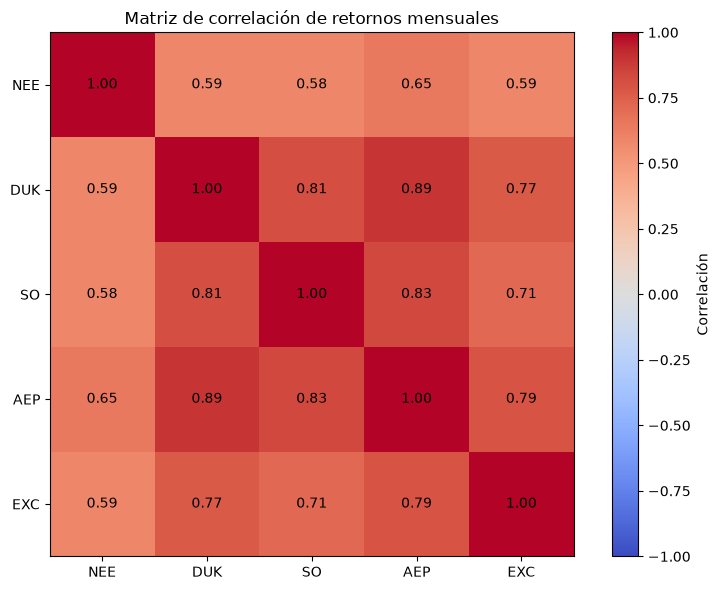

In [7]:
# ============================================================
# Matriz de correlación de los retornos
# ============================================================

matriz_correlacion = retornos.corr()

print("Matriz de correlación:")
display(matriz_correlacion)

# Gráfico de la matriz de correlación
fig, ax = plt.subplots(figsize=(8, 6))

imagen = ax.imshow(
    matriz_correlacion,
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

ax.set_xticks(range(len(tickers)))
ax.set_yticks(range(len(tickers)))
ax.set_xticklabels(tickers)
ax.set_yticklabels(tickers)

# Mostrar el valor de cada correlación dentro de la matriz
for i in range(len(tickers)):
    for j in range(len(tickers)):
        ax.text(
            j,
            i,
            f"{matriz_correlacion.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(imagen, ax=ax, label="Correlación")
plt.title("Matriz de correlación de retornos mensuales")
plt.tight_layout()
plt.show()

### Interpretación de la Etapa 1

Durante el período analizado, **NEE presentó el mayor retorno medio anualizado (9,81%)**, aunque también exhibió la mayor volatilidad anualizada (20,43%). En contraste, **DUK registró la menor volatilidad (17,62%)**, pero también el menor retorno medio anualizado (3,20%). Por lo tanto, el activo históricamente más rentable del portafolio también estuvo asociado a un mayor nivel de riesgo.

Los cinco activos presentan asimetría negativa, lo que indica una mayor presencia relativa de movimientos extremos hacia retornos negativos. Este comportamiento es especialmente marcado en NEE, que presenta una asimetría de -0,8623 y el mayor exceso de curtosis (1,4936).

El test de Jarque-Bera confirma que **NEE es el único activo para el cual se rechaza la hipótesis de normalidad al 5%** (p-value = 0,0001). Para DUK, SO, AEP y EXC no existe evidencia estadística suficiente para rechazar normalidad a este nivel de significancia. Este resultado será relevante posteriormente al calcular el VaR, debido a que el método paramétrico depende del supuesto de normalidad.

Finalmente, las correlaciones entre los activos son todas positivas, aunque su intensidad difiere considerablemente. **NEE presenta las correlaciones más bajas con el resto del portafolio**, aproximadamente entre 0,58 y 0,65, mientras que algunas relaciones entre los demás activos son considerablemente mayores, como DUK-AEP (0,89). En consecuencia, NEE aparece inicialmente como el activo con mayor potencial de diversificación dentro del portafolio, aspecto que se retomará al construir el portafolio de mínima varianza.

# Etapa 2 — ¿Qué explica a cada activo?

En esta etapa se analiza si los retornos de las acciones del portafolio responden a factores de mercado observables o si una parte importante de su comportamiento es idiosincrática.

Se utilizarán como factores macroeconómicos la tasa del Tesoro de Estados Unidos a 10 años (**GS10**), la tasa a 2 años (**GS2**) y el índice de volatilidad **VIX**. Además, se construirá el spread de tasas:

\[
Spread_{10Y-2Y} = GS10 - GS2
\]

Posteriormente se estimará una regresión múltiple para cada activo del portafolio.

In [8]:
# ============================================================
# Descarga de tasas del Tesoro desde FRED
# ============================================================

tasas_diarias = web.DataReader(
    ["GS10", "GS2"],
    "fred",
    fecha_inicio,
    fecha_fin
)

print("Primeras observaciones de las tasas:")
display(tasas_diarias.head())

print("\nÚltimas observaciones:")
display(tasas_diarias.tail())

print("\nValores faltantes:")
display(tasas_diarias.isna().sum())

Primeras observaciones de las tasas:


,GS10,GS2
DATE,,
2016-01-01,2.0900,0.9000
2016-02-01,1.7800,0.7300
2016-03-01,1.8900,0.8800
2016-04-01,1.8100,0.7700
2016-05-01,1.8100,0.8200



Últimas observaciones:


,GS10,GS2
DATE,,
2023-09-01,4.3800,5.0200
2023-10-01,4.8000,5.0700
2023-11-01,4.5000,4.8800
2023-12-01,4.0200,4.4600
2024-01-01,4.0600,4.3200



Valores faltantes:


GS10    0
GS2     0
dtype: int64

In [9]:
# ============================================================
# Descarga del índice VIX desde Yahoo Finance
# ============================================================

vix_diario = yf.download(
    "^VIX",
    start=fecha_inicio,
    end=fecha_fin,
    auto_adjust=False,
    progress=False
)

# Extraer precio de cierre
vix = vix_diario["Close"].copy()

# Convertir a frecuencia mensual usando el último valor disponible
vix_mensual = vix.resample("ME").last()

# Renombrar la columna
vix_mensual.columns = ["VIX"]

print("Dimensión del VIX mensual:", vix_mensual.shape)

print("\nPrimeras observaciones:")
display(vix_mensual.head())

print("\nÚltimas observaciones:")
display(vix_mensual.tail())

print("\nValores faltantes:")
display(vix_mensual.isna().sum())

Dimensión del VIX mensual: (96, 1)

Primeras observaciones:


,VIX
Date,
2016-01-31,20.2000
2016-02-29,20.5500
2016-03-31,13.9500
2016-04-30,15.7000
2016-05-31,14.1900



Últimas observaciones:


,VIX
Date,
2023-08-31,13.5700
2023-09-30,17.5200
2023-10-31,18.1400
2023-11-30,12.9200
2023-12-31,12.4500



Valores faltantes:


VIX    0
dtype: int64

In [10]:
# ============================================================
# Alineación mensual de retornos y factores macroeconómicos
# ============================================================

# Copias para no modificar los datos originales
retornos_reg = retornos.copy()
tasas_reg = tasas_diarias.copy()
vix_reg = vix_mensual.copy()

# Convertir todos los índices a período mensual
retornos_reg.index = retornos_reg.index.to_period("M")
tasas_reg.index = tasas_reg.index.to_period("M")
vix_reg.index = vix_reg.index.to_period("M")

# Construir spread de tasas 10 años - 2 años
tasas_reg["Spread_10Y_2Y"] = tasas_reg["GS10"] - tasas_reg["GS2"]

# Unir retornos y factores usando solamente meses comunes
datos_regresion = pd.concat(
    [
        retornos_reg,
        tasas_reg[["GS10", "GS2", "Spread_10Y_2Y"]],
        vix_reg[["VIX"]]
    ],
    axis=1,
    join="inner"
)

# Mantener la misma ventana efectiva de los retornos
datos_regresion = datos_regresion.loc[retornos_reg.index]

print("Dimensión de la base para regresiones:", datos_regresion.shape)

print("\nPrimeras observaciones:")
display(datos_regresion.head())

print("\nÚltimas observaciones:")
display(datos_regresion.tail())

print("\nValores faltantes:")
display(datos_regresion.isna().sum())

Dimensión de la base para regresiones: (95, 9)

Primeras observaciones:


,NEE,DUK,SO,AEP,EXC,GS10,GS2,Spread_10Y_2Y,VIX
Date,,,,,,,,,
2016-02,0.0099,-0.0136,-0.0152,0.0127,0.0629,1.7800,0.7300,1.0500,20.5500
2016-03,0.0478,0.0826,0.0711,0.0726,0.1300,1.8900,0.8800,1.0100,13.9500
2016-04,-0.0064,-0.0238,-0.0320,-0.0447,-0.0217,1.8100,0.7700,1.0400,15.7000
2016-05,0.0214,-0.0070,-0.0133,0.0192,-0.0236,1.8100,0.8200,0.9900,14.1900
2016-06,0.0821,0.0922,0.0813,0.0796,0.0592,1.6400,0.7300,0.9100,15.6300



Últimas observaciones:


,NEE,DUK,SO,AEP,EXC,GS10,GS2,Spread_10Y_2Y,VIX
Date,,,,,,,,,
2023-08,-0.0929,-0.0529,-0.0658,-0.0778,-0.0425,4.1700,4.9000,-0.7300,13.5700
2023-09,-0.1536,-0.0061,-0.0455,-0.0414,-0.0598,4.3800,5.0200,-0.6400,17.5200
2023-10,0.0175,0.0071,0.0391,0.0042,0.0300,4.8000,5.0700,-0.2700,18.1400
2023-11,0.0036,0.0374,0.0532,0.0517,-0.0111,4.5000,4.8800,-0.3800,12.9200
2023-12,0.0374,0.0503,-0.0122,0.0208,-0.0702,4.0200,4.4600,-0.4400,12.4500



Valores faltantes:


NEE              0
DUK              0
SO               0
AEP              0
EXC              0
GS10             0
GS2              0
Spread_10Y_2Y    0
VIX              0
dtype: int64

In [11]:
# ============================================================
# Análisis de multicolinealidad - VIF
# ============================================================

# Regresores especificados en el enunciado
X_vif = datos_regresion[["GS10", "VIX", "Spread_10Y_2Y"]].copy()

# Agregar constante
X_vif_const = sm.add_constant(X_vif)

# Calcular VIF
vif = pd.DataFrame({
    "Variable": X_vif_const.columns,
    "VIF": [
        variance_inflation_factor(X_vif_const.values, i)
        for i in range(X_vif_const.shape[1])
    ]
})

print("Factores de Inflación de Varianza (VIF):")
display(vif)

print("\nCorrelación entre los regresores:")
display(X_vif.corr())

Factores de Inflación de Varianza (VIF):


,Variable,VIF
0,const,45.8914
1,GS10,2.5829
2,VIX,1.3684
3,Spread_10Y_2Y,2.3618



Correlación entre los regresores:


,GS10,VIX,Spread_10Y_2Y
GS10,1.0000,-0.3058,-0.6891
VIX,-0.3058,1.0000,-0.0931
Spread_10Y_2Y,-0.6891,-0.0931,1.0000


In [12]:
# ============================================================
# Regresiones múltiples para cada activo
# ============================================================

# Variables explicativas
X = datos_regresion[["GS10", "VIX", "Spread_10Y_2Y"]].copy()
X = sm.add_constant(X)

# Diccionarios para guardar modelos y residuos
modelos = {}
residuos = pd.DataFrame(index=datos_regresion.index)

# Tabla resumen
resultados_regresiones = []

for ticker in tickers:
    
    # Variable dependiente
    y = datos_regresion[ticker]
    
    # Estimación OLS
    modelo = sm.OLS(y, X).fit()
    
    # Guardar modelo
    modelos[ticker] = modelo
    
    # Guardar residuos para la Etapa 3
    residuos[ticker] = modelo.resid
    
    # Guardar resultados principales
    resultados_regresiones.append({
        "Activo": ticker,
        "R2": modelo.rsquared,
        "R2 ajustado": modelo.rsquared_adj,
        "Beta GS10": modelo.params["GS10"],
        "p GS10": modelo.pvalues["GS10"],
        "Beta VIX": modelo.params["VIX"],
        "p VIX": modelo.pvalues["VIX"],
        "Beta Spread": modelo.params["Spread_10Y_2Y"],
        "p Spread": modelo.pvalues["Spread_10Y_2Y"]
    })

tabla_regresiones = pd.DataFrame(resultados_regresiones).set_index("Activo")

print("Resumen de las regresiones:")
display(tabla_regresiones)

print("\nDimensión de los residuos guardados:", residuos.shape)

Resumen de las regresiones:


,R2,R2 ajustado,Beta GS10,p GS10,Beta VIX,p VIX,Beta Spread,p Spread
Activo,,,,,,,,
NEE,0.1128,0.0836,-0.0225,0.0206,-0.0026,0.0046,-0.0141,0.3419
DUK,0.0819,0.0516,-0.0086,0.3061,-0.0021,0.0089,-0.0045,0.7307
SO,0.1052,0.0757,-0.0161,0.0750,-0.0027,0.0016,-0.0191,0.1721
AEP,0.0890,0.0590,-0.0066,0.4675,-0.0023,0.0082,-0.0009,0.9490
EXC,0.1110,0.0817,-0.0043,0.6274,-0.0020,0.0160,0.0118,0.3919



Dimensión de los residuos guardados: (95, 5)


Activo con mayor R²: NEE (0.1128)
Activo con menor R²: DUK (0.0819)


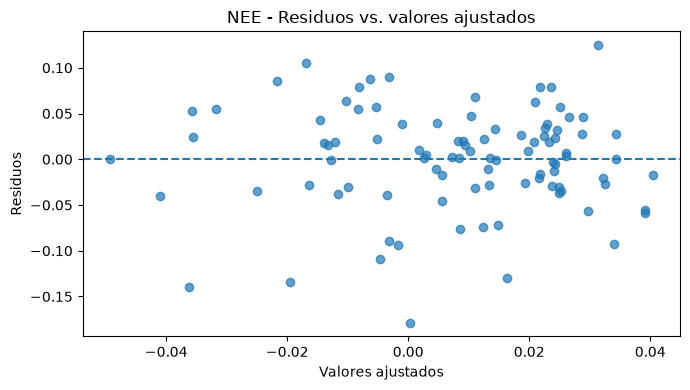

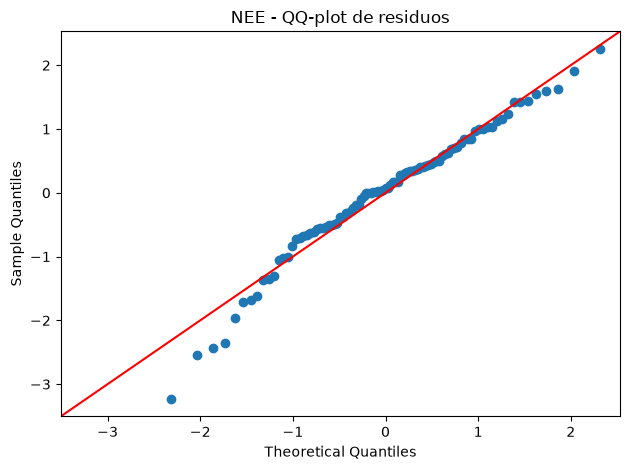


Test Breusch-Pagan - NEE
LM Statistic : 4.2862
LM p-value   : 0.2322
F Statistic  : 1.4333
F p-value    : 0.2383
--------------------------------------------------


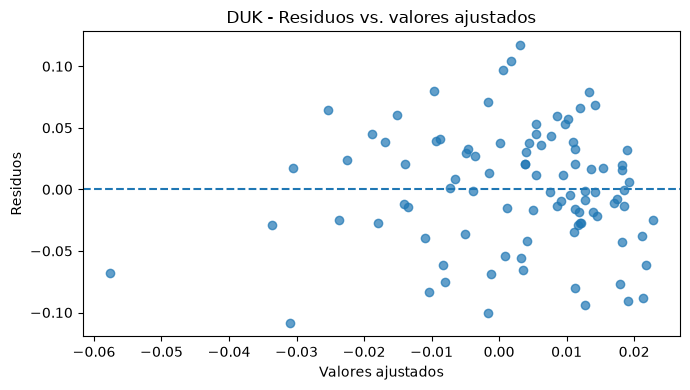

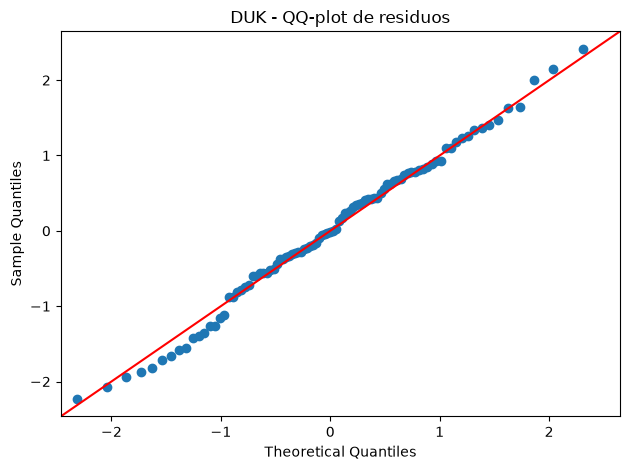


Test Breusch-Pagan - DUK
LM Statistic : 3.1310
LM p-value   : 0.3719
F Statistic  : 1.0338
F p-value    : 0.3815
--------------------------------------------------


In [13]:
# ============================================================
# Diagnóstico de los modelos con mejor y peor R²
# ============================================================

mejor_activo = tabla_regresiones["R2"].idxmax()
peor_activo = tabla_regresiones["R2"].idxmin()

print(f"Activo con mayor R²: {mejor_activo} "
      f"({tabla_regresiones.loc[mejor_activo, 'R2']:.4f})")

print(f"Activo con menor R²: {peor_activo} "
      f"({tabla_regresiones.loc[peor_activo, 'R2']:.4f})")


for ticker in [mejor_activo, peor_activo]:

    modelo = modelos[ticker]

    # --------------------------------------------------------
    # 1. Residuos vs valores ajustados
    # --------------------------------------------------------
    plt.figure(figsize=(7, 4))
    plt.scatter(modelo.fittedvalues, modelo.resid, alpha=0.7)
    plt.axhline(y=0, linestyle="--")
    plt.xlabel("Valores ajustados")
    plt.ylabel("Residuos")
    plt.title(f"{ticker} - Residuos vs. valores ajustados")
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 2. QQ-plot
    # --------------------------------------------------------
    sm.qqplot(modelo.resid, line="45", fit=True)
    plt.title(f"{ticker} - QQ-plot de residuos")
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 3. Test de Breusch-Pagan
    # --------------------------------------------------------
    bp = het_breuschpagan(modelo.resid, modelo.model.exog)

    print(f"\nTest Breusch-Pagan - {ticker}")
    print(f"LM Statistic : {bp[0]:.4f}")
    print(f"LM p-value   : {bp[1]:.4f}")
    print(f"F Statistic  : {bp[2]:.4f}")
    print(f"F p-value    : {bp[3]:.4f}")
    print("-" * 50)

### Interpretación de la Etapa 2

Los resultados muestran que los factores macroeconómicos considerados explican solo una fracción del comportamiento mensual de las acciones del portafolio. Los coeficientes de determinación son relativamente bajos, con valores de R² entre 8,19% y 11,28%. **NEE presenta el mayor R² (11,28%)**, mientras que **DUK registra el menor (8,19%)**. Por lo tanto, una parte importante de las variaciones de los retornos permanece sin explicar por estos factores y puede estar asociada a componentes idiosincráticos u otros factores no incluidos en el modelo.

El **VIX resulta estadísticamente significativo al 5% para los cinco activos**, presentando en todos los casos un coeficiente negativo. Esto indica que, durante el período analizado, aumentos en la volatilidad esperada del mercado estuvieron asociados con menores retornos de las acciones del portafolio Utilities, manteniendo constantes los demás factores.

La tasa GS10 presenta un coeficiente negativo para todos los activos, aunque solamente resulta estadísticamente significativa al 5% para NEE (p-value = 0,0206). Por su parte, el spread entre las tasas a 10 y 2 años no resulta estadísticamente significativo al 5% para ninguno de los cinco activos.

El análisis de multicolinealidad no muestra un problema severo. Aunque GS10 y el spread presentan una correlación de -0,6891, sus VIF son 2,58 y 2,36, respectivamente, por lo que se mantienen ambos regresores según la especificación planteada.

En los diagnósticos de los modelos con mayor y menor R², el test de Breusch-Pagan no permite rechazar la hipótesis de homocedasticidad ni para NEE (p-value = 0,2322) ni para DUK (p-value = 0,3719). Sin embargo, el QQ-plot de NEE muestra desviaciones más visibles en las colas, coherentes con la evidencia de no-normalidad encontrada en la Etapa 1. DUK presenta un ajuste visual más cercano a la distribución normal.

Finalmente, los residuos de las cinco regresiones fueron almacenados para analizar en la siguiente etapa si la varianza del componente no explicado permanece constante en el tiempo o presenta agrupamiento de volatilidad.

# Etapa 3 — La volatilidad no es constante

En esta etapa se analiza si la varianza de los residuos obtenidos en las regresiones de la Etapa 2 permanece constante en el tiempo o presenta **heterocedasticidad condicional**.

Primero se aplicará el test **ARCH-LM** a los residuos de cada activo. Posteriormente se estimará un modelo **GARCH(1,1)** para obtener una serie de volatilidad condicional y compararla con la volatilidad histórica móvil de 12 meses.

In [14]:
# ============================================================
# Test ARCH-LM sobre los residuos de las regresiones
# ============================================================

resultados_arch = []

for ticker in tickers:
    
    # Test ARCH-LM con 12 rezagos
    arch_test = het_arch(residuos[ticker], nlags=12)
    
    resultados_arch.append({
        "Activo": ticker,
        "LM Statistic": arch_test[0],
        "LM p-value": arch_test[1],
        "F Statistic": arch_test[2],
        "F p-value": arch_test[3],
        "Efecto ARCH al 5%": "Sí" if arch_test[1] < 0.05 else "No"
    })

tabla_arch = pd.DataFrame(resultados_arch).set_index("Activo")

print("Test ARCH-LM sobre los residuos:")
display(tabla_arch)

Test ARCH-LM sobre los residuos:


,LM Statistic,LM p-value,F Statistic,F p-value,Efecto ARCH al 5%
Activo,,,,,
NEE,10.0390,0.6125,0.8026,0.6465,No
DUK,15.7737,0.2018,1.3687,0.2018,No
SO,7.1484,0.8477,0.5497,0.8740,No
AEP,11.5720,0.4806,0.9451,0.5085,No
EXC,13.0707,0.3639,1.0903,0.3818,No


In [15]:
# ============================================================
# Modelos GARCH(1,1) para los residuos de cada activo
# ============================================================

modelos_garch = {}
resultados_garch = {}

# DataFrame donde guardaremos las volatilidades condicionales
volatilidad_garch = pd.DataFrame(index=residuos.index)

for ticker in tickers:
    
    # Escalar residuos a porcentaje para mejorar estabilidad numérica
    residuo_pct = residuos[ticker] * 100
    
    # Modelo GARCH(1,1)
    modelo_garch = arch_model(
        residuo_pct,
        mean="Zero",
        vol="GARCH",
        p=1,
        q=1,
        dist="normal"
    )
    
    # Ajustar modelo sin imprimir iteraciones
    ajuste = modelo_garch.fit(disp="off")
    
    # Guardar ajuste
    modelos_garch[ticker] = ajuste
    
    # Volatilidad condicional nuevamente en escala decimal
    volatilidad_garch[ticker] = ajuste.conditional_volatility / 100
    
    # Guardar parámetros principales
    resultados_garch[ticker] = {
        "omega": ajuste.params["omega"],
        "alpha": ajuste.params["alpha[1]"],
        "beta": ajuste.params["beta[1]"],
        "alpha + beta": ajuste.params["alpha[1]"] + ajuste.params["beta[1]"]
    }

tabla_garch = pd.DataFrame(resultados_garch).T

print("Parámetros de los modelos GARCH(1,1):")
display(tabla_garch)

print("\nDimensión de la volatilidad condicional guardada:",
      volatilidad_garch.shape)

Parámetros de los modelos GARCH(1,1):


,omega,alpha,beta,alpha + beta
NEE,1.2172,0.1137,0.8605,0.9742
DUK,0.0528,0.0000,1.0000,1.0000
SO,0.1077,0.0000,1.0000,1.0000
AEP,2.8426,0.0553,0.8428,0.8981
EXC,3.3173,0.0000,0.8686,0.8686



Dimensión de la volatilidad condicional guardada: (95, 5)


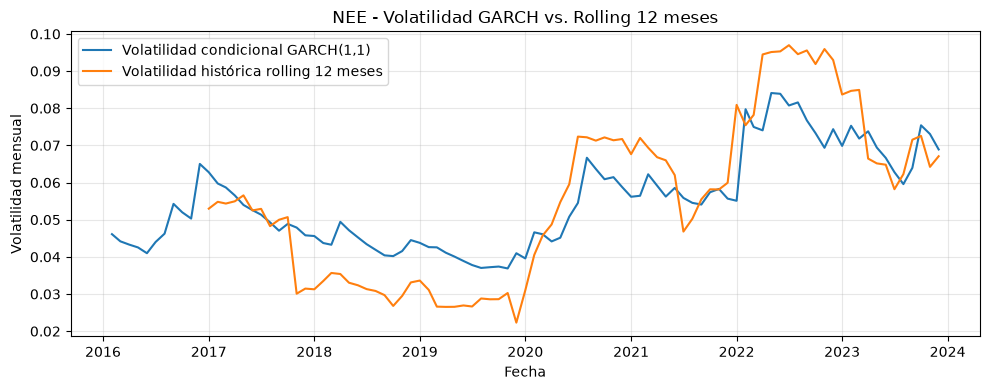

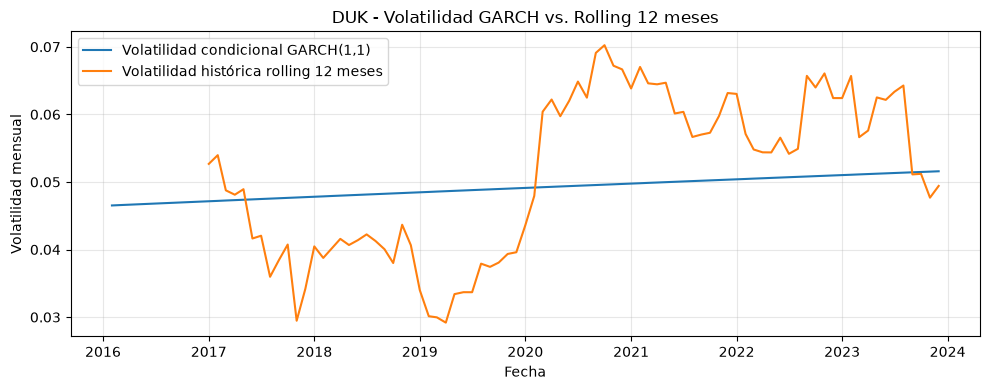

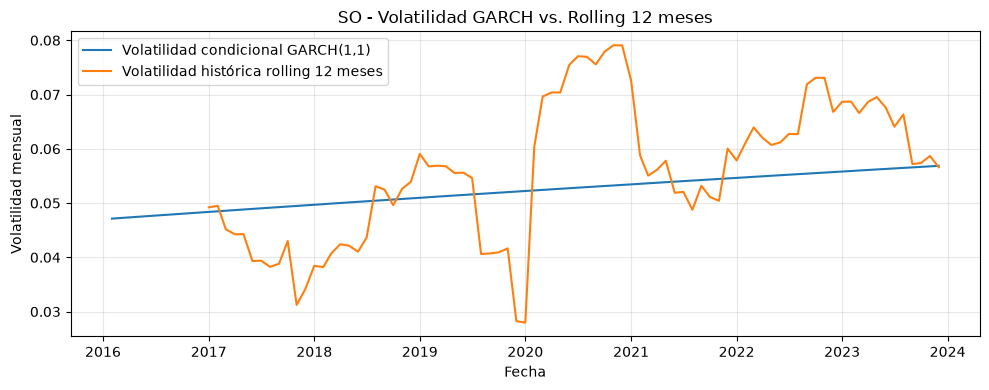

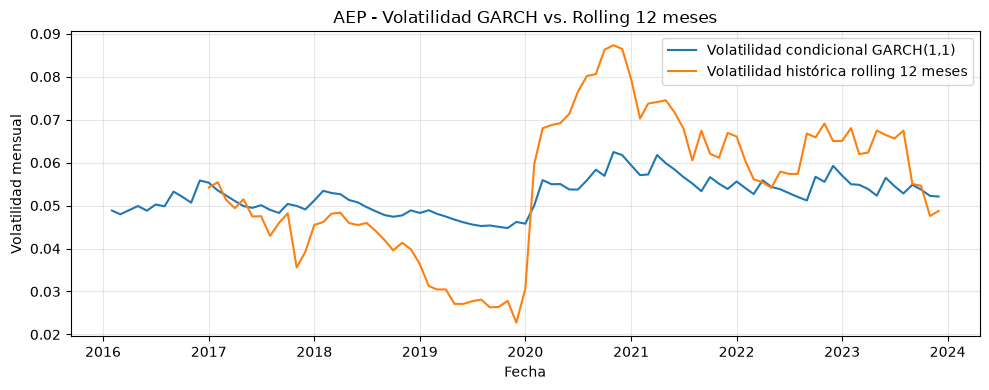

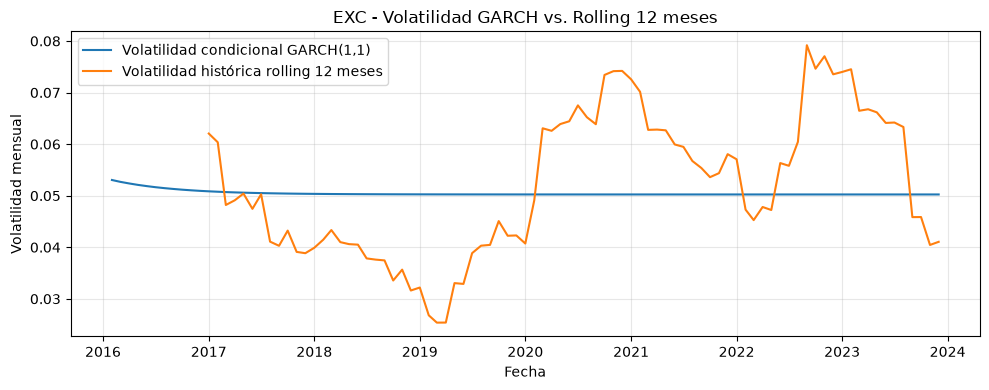

In [16]:
# ============================================================
# Comparación: volatilidad GARCH vs. rolling de 12 meses
# ============================================================

# Volatilidad histórica móvil de 12 meses
volatilidad_rolling_12m = retornos_reg.rolling(window=12).std()

# Graficar cada activo por separado
for ticker in tickers:

    plt.figure(figsize=(10, 4))

    plt.plot(
        volatilidad_garch.index.to_timestamp(),
        volatilidad_garch[ticker],
        label="Volatilidad condicional GARCH(1,1)"
    )

    plt.plot(
        volatilidad_rolling_12m.index.to_timestamp(),
        volatilidad_rolling_12m[ticker],
        label="Volatilidad histórica rolling 12 meses"
    )

    plt.title(f"{ticker} - Volatilidad GARCH vs. Rolling 12 meses")
    plt.xlabel("Fecha")
    plt.ylabel("Volatilidad mensual")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [17]:
# ============================================================
# Resumen de volatilidad condicional y estimación para Etapa 4
# ============================================================

# Promedio histórico de la volatilidad GARCH
promedio_garch = volatilidad_garch.mean()

# Mes de máxima volatilidad GARCH por activo
fecha_max_garch = volatilidad_garch.idxmax()

# Valor máximo de volatilidad GARCH
max_garch = volatilidad_garch.max()

# Promedio de los últimos 12 meses:
# estimación de riesgo que utilizaremos en la Etapa 4
vol_garch_etapa4 = volatilidad_garch.tail(12).mean()

resumen_volatilidad = pd.DataFrame({
    "Promedio GARCH": promedio_garch,
    "Máximo GARCH": max_garch,
    "Fecha máximo": fecha_max_garch.astype(str),
    "Promedio últimos 12m": vol_garch_etapa4
})

print("Resumen de volatilidad condicional:")
display(resumen_volatilidad)

print("\nVolatilidades GARCH que se utilizarán en la Etapa 4:")
display(vol_garch_etapa4)

Resumen de volatilidad condicional:


,Promedio GARCH,Máximo GARCH,Fecha máximo,Promedio últimos 12m
NEE,0.0550,0.0841,2022-05,0.0692
DUK,0.0491,0.0516,2023-12,0.0513
SO,0.0521,0.0569,2023-12,0.0563
AEP,0.0524,0.0625,2020-11,0.0541
EXC,0.0505,0.0530,2016-02,0.0502



Volatilidades GARCH que se utilizarán en la Etapa 4:


NEE   0.0692
DUK   0.0513
SO    0.0563
AEP   0.0541
EXC   0.0502
dtype: float64

### Interpretación de la Etapa 3

El test ARCH-LM no entrega evidencia estadísticamente significativa de heterocedasticidad condicional al 5% para ninguno de los cinco activos. Por lo tanto, en esta muestra no se rechaza la hipótesis de ausencia de efectos ARCH. Sin embargo, siguiendo la metodología solicitada, se estimaron modelos GARCH(1,1) para todos los activos con el objetivo de obtener una medida dinámica y alternativa de riesgo.

Los resultados muestran comportamientos heterogéneos. NEE presenta una elevada persistencia de volatilidad, con α + β = 0,9742, mientras que AEP y EXC presentan valores de 0,8981 y 0,8686, respectivamente. En DUK y SO la estimación se encuentra prácticamente en una solución de frontera, con α cercano a cero y β cercano a uno. En estos casos, la volatilidad condicional estimada cambia muy poco en el tiempo, por lo que estos resultados deben interpretarse con cautela y en conjunto con la ausencia de significancia en el test ARCH-LM.

La comparación con la volatilidad histórica móvil de 12 meses muestra que ambas medidas pueden entregar señales de riesgo diferentes. En particular, NEE y AEP presentan una dinámica condicional más visible, mientras que para DUK, SO y especialmente EXC el GARCH genera trayectorias considerablemente más estables. Esto evidencia que la elección de la medida de volatilidad puede afectar la estimación del riesgo y, en consecuencia, los pesos de un portafolio optimizado.

Para la siguiente etapa se utilizará como estimación condicional de riesgo el promedio de la volatilidad GARCH de los últimos 12 meses de cada activo, evitando depender exclusivamente de la observación del último mes.

# Etapa 4 — Dos formas de optimizar el mismo portafolio

En esta etapa se construye la frontera eficiente utilizando inicialmente la matriz de covarianza histórica de los retornos mensuales. A partir de ella se obtienen el portafolio de mínima varianza y el portafolio de máximo Sharpe.

Posteriormente, se reemplazan las volatilidades individuales de la matriz de covarianza por las volatilidades condicionales estimadas mediante GARCH(1,1), manteniendo las correlaciones históricas entre los activos. Esto permite analizar cómo cambia la asignación óptima cuando se reconoce que el riesgo puede variar en el tiempo.

In [18]:
# ============================================================
# Preparación de datos para optimización del portafolio
# ============================================================

# Retornos medios mensuales de los activos
retornos_medios_mensuales = retornos.mean()

# Retornos esperados anualizados
retornos_esperados_anuales = retornos_medios_mensuales * 12

# Matriz de covarianza mensual histórica
cov_mensual = retornos.cov()

# Matriz de covarianza anualizada
cov_anual = cov_mensual * 12

print("Retornos esperados anualizados:")
display(retornos_esperados_anuales.to_frame("Retorno esperado anual"))

print("\nMatriz de covarianza anualizada:")
display(cov_anual)

Retornos esperados anualizados:


,Retorno esperado anual
Ticker,
NEE,0.0981
DUK,0.0320
SO,0.0455
AEP,0.0362
EXC,0.0672



Matriz de covarianza anualizada:


Ticker,NEE,DUK,SO,AEP,EXC
Ticker,,,,,
NEE,0.0417,0.0212,0.0227,0.0253,0.0227
DUK,0.0212,0.0311,0.0272,0.0300,0.0257
SO,0.0227,0.0272,0.0364,0.0303,0.0257
AEP,0.0253,0.0300,0.0303,0.0365,0.0286
EXC,0.0227,0.0257,0.0257,0.0286,0.0357


In [19]:
# ============================================================
# Portafolio de mínima varianza - Covarianza histórica
# ============================================================

n_activos = len(tickers)

# Pesos iniciales equiponderados
pesos_iniciales = np.ones(n_activos) / n_activos

# Restricción: la suma de los pesos debe ser igual a 1
restricciones = ({
    "type": "eq",
    "fun": lambda w: np.sum(w) - 1
})

# Límites: no se permiten ventas en corto
limites = tuple((0, 1) for _ in range(n_activos))

# Función de volatilidad del portafolio
def volatilidad_portafolio(pesos, matriz_cov):
    return np.sqrt(
        np.dot(pesos.T, np.dot(matriz_cov, pesos))
    )

# Optimización de mínima varianza
opt_min_var = minimize(
    volatilidad_portafolio,
    pesos_iniciales,
    args=(cov_anual,),
    method="SLSQP",
    bounds=limites,
    constraints=restricciones
)

# Pesos óptimos
pesos_min_var = opt_min_var.x

# Retorno y volatilidad del portafolio
retorno_min_var = np.dot(
    pesos_min_var,
    retornos_esperados_anuales
)

vol_min_var = volatilidad_portafolio(
    pesos_min_var,
    cov_anual
)

# Tabla de resultados
tabla_min_var = pd.DataFrame({
    "Activo": tickers,
    "Peso": pesos_min_var
}).set_index("Activo")

print("¿Optimización exitosa?:", opt_min_var.success)

print("\nPesos del portafolio de mínima varianza:")
display(tabla_min_var)

print(f"Suma de los pesos: {pesos_min_var.sum():.4f}")
print(f"Retorno esperado anual: {retorno_min_var:.4%}")
print(f"Volatilidad anual: {vol_min_var:.4%}")

¿Optimización exitosa?: True

Pesos del portafolio de mínima varianza:


,Peso
Activo,
NEE,0.2553
DUK,0.4122
SO,0.1308
AEP,0.0000
EXC,0.2017


Suma de los pesos: 1.0000
Retorno esperado anual: 5.7763%
Volatilidad anual: 16.4113%


In [20]:
# ============================================================
# Portafolio de máximo Sharpe - Covarianza histórica
# ============================================================

# Tasa libre de riesgo
rf = 0.0

# Función para calcular el Sharpe negativo
# (scipy minimiza, por eso usamos el negativo)
def sharpe_negativo(pesos, retornos_esperados, matriz_cov, rf=0.0):
    
    retorno_port = np.dot(pesos, retornos_esperados)
    vol_port = np.sqrt(
        np.dot(pesos.T, np.dot(matriz_cov, pesos))
    )
    
    sharpe = (retorno_port - rf) / vol_port
    
    return -sharpe


# Optimización
opt_max_sharpe_hist = minimize(
    sharpe_negativo,
    pesos_iniciales,
    args=(retornos_esperados_anuales, cov_anual, rf),
    method="SLSQP",
    bounds=limites,
    constraints=restricciones
)

# Pesos óptimos
pesos_max_sharpe_hist = opt_max_sharpe_hist.x

# Retorno esperado
retorno_max_sharpe_hist = np.dot(
    pesos_max_sharpe_hist,
    retornos_esperados_anuales
)

# Volatilidad
vol_max_sharpe_hist = volatilidad_portafolio(
    pesos_max_sharpe_hist,
    cov_anual
)

# Sharpe
sharpe_max_hist = (
    retorno_max_sharpe_hist - rf
) / vol_max_sharpe_hist

# Tabla
tabla_max_sharpe_hist = pd.DataFrame({
    "Activo": tickers,
    "Peso": pesos_max_sharpe_hist
}).set_index("Activo")

print("¿Optimización exitosa?:", opt_max_sharpe_hist.success)

print("\nPesos del portafolio de máximo Sharpe (histórico):")
display(tabla_max_sharpe_hist)

print(f"Suma de los pesos: {pesos_max_sharpe_hist.sum():.4f}")
print(f"Retorno esperado anual: {retorno_max_sharpe_hist:.4%}")
print(f"Volatilidad anual: {vol_max_sharpe_hist:.4%}")
print(f"Ratio de Sharpe: {sharpe_max_hist:.4f}")

¿Optimización exitosa?: True

Pesos del portafolio de máximo Sharpe (histórico):


,Peso
Activo,
NEE,0.7741
DUK,0.0000
SO,0.0000
AEP,0.0000
EXC,0.2259


Suma de los pesos: 1.0000
Retorno esperado anual: 9.1152%
Volatilidad anual: 18.6430%
Ratio de Sharpe: 0.4889


In [21]:
# ============================================================
# Matriz de covarianza basada en volatilidades GARCH
# ============================================================

# Matriz de correlaciones históricas
corr_historica = retornos.corr()

# Volatilidades GARCH mensuales de la Etapa 3
# anualizadas para mantener consistencia con la optimización
vol_garch_anual = vol_garch_etapa4 * np.sqrt(12)

# Matriz diagonal de volatilidades GARCH anualizadas
D_garch = np.diag(vol_garch_anual.loc[tickers].values)

# Mantener correlaciones históricas y reemplazar volatilidades
cov_garch_anual = pd.DataFrame(
    D_garch @ corr_historica.loc[tickers, tickers].values @ D_garch,
    index=tickers,
    columns=tickers
)

print("Volatilidades GARCH anualizadas:")
display(vol_garch_anual.to_frame("Volatilidad GARCH anual"))

print("\nMatriz de covarianza con volatilidades GARCH:")
display(cov_garch_anual)

Volatilidades GARCH anualizadas:


,Volatilidad GARCH anual
NEE,0.2398
DUK,0.1777
SO,0.1952
AEP,0.1875
EXC,0.1740



Matriz de covarianza con volatilidades GARCH:


,NEE,DUK,SO,AEP,EXC
NEE,0.0575,0.0251,0.0272,0.0291,0.0245
DUK,0.0251,0.0316,0.0280,0.0297,0.0238
SO,0.0272,0.0280,0.0381,0.0304,0.0243
AEP,0.0291,0.0297,0.0304,0.0352,0.0258
EXC,0.0245,0.0238,0.0243,0.0258,0.0303


In [22]:
# ============================================================
# Portafolio de máximo Sharpe - Riesgo GARCH
# ============================================================

opt_max_sharpe_garch = minimize(
    sharpe_negativo,
    pesos_iniciales,
    args=(retornos_esperados_anuales, cov_garch_anual, rf),
    method="SLSQP",
    bounds=limites,
    constraints=restricciones
)

# Pesos óptimos
pesos_max_sharpe_garch = opt_max_sharpe_garch.x

# Retorno esperado
retorno_max_sharpe_garch = np.dot(
    pesos_max_sharpe_garch,
    retornos_esperados_anuales
)

# Volatilidad utilizando la nueva matriz GARCH
vol_max_sharpe_garch = volatilidad_portafolio(
    pesos_max_sharpe_garch,
    cov_garch_anual
)

# Ratio de Sharpe
sharpe_max_garch = (
    retorno_max_sharpe_garch - rf
) / vol_max_sharpe_garch

# Tabla de resultados
tabla_max_sharpe_garch = pd.DataFrame({
    "Activo": tickers,
    "Peso": pesos_max_sharpe_garch
}).set_index("Activo")

print("¿Optimización exitosa?:", opt_max_sharpe_garch.success)

print("\nPesos del portafolio de máximo Sharpe (GARCH):")
display(tabla_max_sharpe_garch)

print(f"Suma de los pesos: {pesos_max_sharpe_garch.sum():.4f}")
print(f"Retorno esperado anual: {retorno_max_sharpe_garch:.4%}")
print(f"Volatilidad anual GARCH: {vol_max_sharpe_garch:.4%}")
print(f"Ratio de Sharpe GARCH: {sharpe_max_garch:.4f}")

¿Optimización exitosa?: True

Pesos del portafolio de máximo Sharpe (GARCH):


,Peso
Activo,
NEE,0.4760
DUK,0.0000
SO,0.0000
AEP,0.0000
EXC,0.5240


Suma de los pesos: 1.0000
Retorno esperado anual: 8.1922%
Volatilidad anual GARCH: 18.3249%
Ratio de Sharpe GARCH: 0.4471


Comparación de los portafolios de máximo Sharpe:


,Máx. Sharpe Histórico,Máx. Sharpe GARCH,Cambio
NEE,0.7741,0.4760,-0.2981
DUK,0.0000,0.0000,0.0000
SO,0.0000,0.0000,0.0000
AEP,0.0000,0.0000,0.0000
EXC,0.2259,0.5240,0.2981


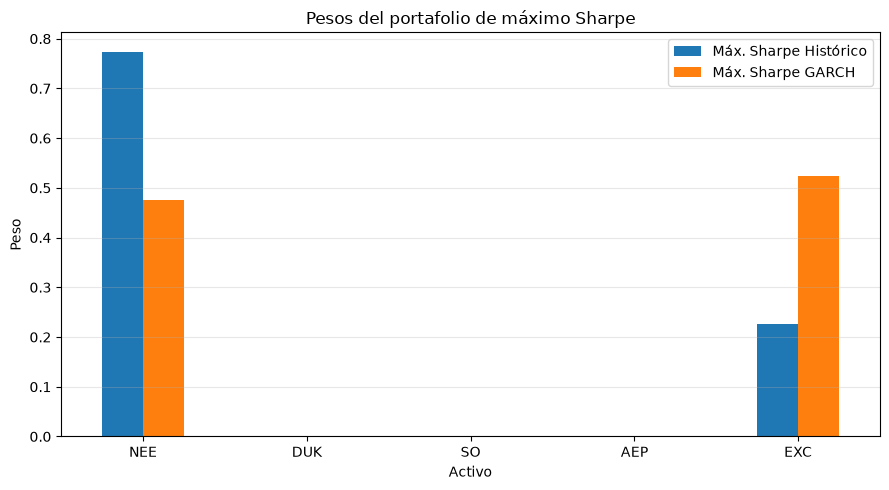

In [23]:
# ============================================================
# Comparación de pesos: Máximo Sharpe histórico vs. GARCH
# ============================================================

comparacion_pesos = pd.DataFrame({
    "Máx. Sharpe Histórico": pesos_max_sharpe_hist,
    "Máx. Sharpe GARCH": pesos_max_sharpe_garch
}, index=tickers)

comparacion_pesos["Cambio"] = (
    comparacion_pesos["Máx. Sharpe GARCH"]
    - comparacion_pesos["Máx. Sharpe Histórico"]
)

print("Comparación de los portafolios de máximo Sharpe:")
display(comparacion_pesos)

# Gráfico comparativo
ax = comparacion_pesos[
    ["Máx. Sharpe Histórico", "Máx. Sharpe GARCH"]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Pesos del portafolio de máximo Sharpe")
plt.xlabel("Activo")
plt.ylabel("Peso")
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# Correlación promedio y portafolio de mínima varianza
# ============================================================

correlacion_promedio = {}

for ticker in tickers:
    
    # Correlaciones del activo con los demás,
    # excluyendo su correlación consigo mismo
    correlaciones_otros = corr_historica.loc[
        ticker,
        corr_historica.columns != ticker
    ]
    
    correlacion_promedio[ticker] = correlaciones_otros.mean()

correlacion_promedio = pd.Series(
    correlacion_promedio,
    name="Correlación promedio"
)

# Tabla comparativa
tabla_diversificacion = pd.DataFrame({
    "Correlación promedio": correlacion_promedio,
    "Peso mínima varianza": pesos_min_var
})

print("Correlación promedio y peso en mínima varianza:")
display(tabla_diversificacion)

# Identificar los activos relevantes
activo_menor_corr = correlacion_promedio.idxmin()
activo_mayor_peso_minvar = tabla_diversificacion[
    "Peso mínima varianza"
].idxmax()

print(
    f"\nActivo con menor correlación promedio: "
    f"{activo_menor_corr} "
    f"({correlacion_promedio[activo_menor_corr]:.4f})"
)

print(
    f"Activo con mayor peso en mínima varianza: "
    f"{activo_mayor_peso_minvar} "
    f"({tabla_diversificacion.loc[activo_mayor_peso_minvar, 'Peso mínima varianza']:.4f})"
)

Correlación promedio y peso en mínima varianza:


,Correlación promedio,Peso mínima varianza
NEE,0.6015,0.2553
DUK,0.7646,0.4122
SO,0.7334,0.1308
AEP,0.7900,0.0000
EXC,0.7159,0.2017



Activo con menor correlación promedio: NEE (0.6015)
Activo con mayor peso en mínima varianza: DUK (0.4122)


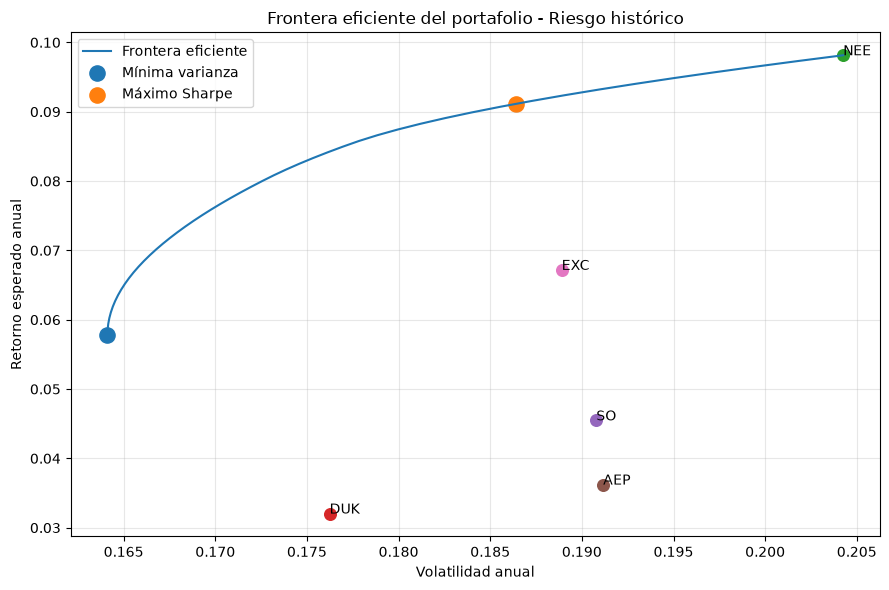

In [25]:
# ============================================================
# Frontera eficiente - Matriz de covarianza histórica
# ============================================================

# Rango de retornos objetivo
retornos_objetivo = np.linspace(
    retorno_min_var,
    retornos_esperados_anuales.max(),
    50
)

volatilidades_frontera = []
retornos_frontera = []

for retorno_objetivo in retornos_objetivo:

    # Restricciones:
    # 1. Los pesos suman 1
    # 2. El portafolio alcanza el retorno objetivo
    restricciones_frontera = (
        {
            "type": "eq",
            "fun": lambda w: np.sum(w) - 1
        },
        {
            "type": "eq",
            "fun": lambda w, r=retorno_objetivo:
                np.dot(w, retornos_esperados_anuales) - r
        }
    )

    resultado = minimize(
        volatilidad_portafolio,
        pesos_iniciales,
        args=(cov_anual,),
        method="SLSQP",
        bounds=limites,
        constraints=restricciones_frontera
    )

    if resultado.success:
        volatilidades_frontera.append(resultado.fun)
        retornos_frontera.append(retorno_objetivo)


# ============================================================
# Gráfico
# ============================================================

plt.figure(figsize=(9, 6))

# Frontera eficiente
plt.plot(
    volatilidades_frontera,
    retornos_frontera,
    label="Frontera eficiente"
)

# Portafolio mínima varianza
plt.scatter(
    vol_min_var,
    retorno_min_var,
    s=120,
    label="Mínima varianza"
)

# Portafolio máximo Sharpe histórico
plt.scatter(
    vol_max_sharpe_hist,
    retorno_max_sharpe_hist,
    s=120,
    label="Máximo Sharpe"
)

# Activos individuales
vol_activos = np.sqrt(np.diag(cov_anual))

for i, ticker in enumerate(tickers):
    plt.scatter(
        vol_activos[i],
        retornos_esperados_anuales.iloc[i],
        s=70
    )
    
    plt.annotate(
        ticker,
        (
            vol_activos[i],
            retornos_esperados_anuales.iloc[i]
        )
    )

plt.title("Frontera eficiente del portafolio - Riesgo histórico")
plt.xlabel("Volatilidad anual")
plt.ylabel("Retorno esperado anual")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# ETAPA 5 — ¿Cuánto se puede perder?
# VaR histórico del portafolio de máximo Sharpe
# ============================================================

# Retornos mensuales del portafolio
retornos_portafolio = retornos.dot(pesos_max_sharpe_hist)

# VaR histórico
var_95 = -np.percentile(retornos_portafolio, 5)
var_99 = -np.percentile(retornos_portafolio, 1)

print("VaR histórico del portafolio de máximo Sharpe:")
print(f"VaR 95% mensual: {var_95:.4%}")
print(f"VaR 99% mensual: {var_99:.4%}")

print("\nEstadísticas del portafolio:")
print(f"Retorno mensual promedio: {retornos_portafolio.mean():.4%}")
print(f"Volatilidad mensual: {retornos_portafolio.std():.4%}")
print(f"Peor retorno mensual observado: {retornos_portafolio.min():.4%}")

VaR histórico del portafolio de máximo Sharpe:
VaR 95% mensual: 9.4962%
VaR 99% mensual: 13.7416%

Estadísticas del portafolio:
Retorno mensual promedio: 0.7596%
Volatilidad mensual: 5.3818%
Peor retorno mensual observado: -14.0521%


In [27]:
# ============================================================
# PASO 37 — Expected Shortfall (CVaR)
# ============================================================

# Percentiles de retorno que determinan las colas
umbral_95 = np.percentile(retornos_portafolio, 5)
umbral_99 = np.percentile(retornos_portafolio, 1)

# Expected Shortfall:
# pérdida promedio cuando el retorno cae por debajo del VaR
es_95 = -retornos_portafolio[
    retornos_portafolio <= umbral_95
].mean()

es_99 = -retornos_portafolio[
    retornos_portafolio <= umbral_99
].mean()

print("Expected Shortfall (CVaR) del portafolio:")
print(f"ES 95% mensual: {es_95:.4%}")
print(f"ES 99% mensual: {es_99:.4%}")

print("\nComparación VaR vs. Expected Shortfall:")
print(f"VaR 95%: {var_95:.4%} | ES 95%: {es_95:.4%}")
print(f"VaR 99%: {var_99:.4%} | ES 99%: {es_99:.4%}")

Expected Shortfall (CVaR) del portafolio:
ES 95% mensual: 12.1547%
ES 99% mensual: 14.0521%

Comparación VaR vs. Expected Shortfall:
VaR 95%: 9.4962% | ES 95%: 12.1547%
VaR 99%: 13.7416% | ES 99%: 14.0521%


In [28]:
# ============================================================
# PASO 38 — VaR paramétrico bajo distribución Normal
# ============================================================

from scipy.stats import norm

# Media y volatilidad mensual del portafolio
mu_port = retornos_portafolio.mean()
sigma_port = retornos_portafolio.std()

# Valores críticos de la distribución normal
z_95 = norm.ppf(0.05)
z_99 = norm.ppf(0.01)

# VaR paramétrico
var_normal_95 = -(mu_port + z_95 * sigma_port)
var_normal_99 = -(mu_port + z_99 * sigma_port)

print("VaR paramétrico (Normal):")
print(f"VaR Normal 95% mensual: {var_normal_95:.4%}")
print(f"VaR Normal 99% mensual: {var_normal_99:.4%}")

print("\nComparación con VaR histórico:")
print(f"95% | Histórico: {var_95:.4%} | Normal: {var_normal_95:.4%}")
print(f"99% | Histórico: {var_99:.4%} | Normal: {var_normal_99:.4%}")

VaR paramétrico (Normal):
VaR Normal 95% mensual: 8.0926%
VaR Normal 99% mensual: 11.7603%

Comparación con VaR histórico:
95% | Histórico: 9.4962% | Normal: 8.0926%
99% | Histórico: 13.7416% | Normal: 11.7603%


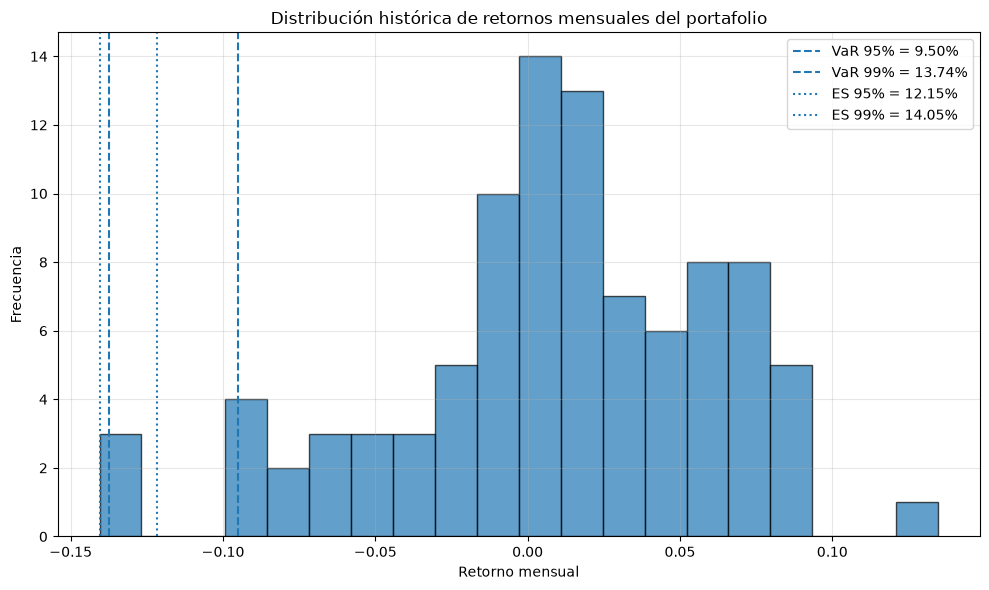

In [29]:
# ============================================================
# PASO 39 — Distribución de retornos y medidas de riesgo
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    retornos_portafolio,
    bins=20,
    alpha=0.7,
    edgecolor="black"
)

# Líneas de VaR (en términos de retorno negativo)
plt.axvline(-var_95, linestyle="--",
            label=f"VaR 95% = {var_95:.2%}")

plt.axvline(-var_99, linestyle="--",
            label=f"VaR 99% = {var_99:.2%}")

# Expected Shortfall
plt.axvline(-es_95, linestyle=":",
            label=f"ES 95% = {es_95:.2%}")

plt.axvline(-es_99, linestyle=":",
            label=f"ES 99% = {es_99:.2%}")

plt.title("Distribución histórica de retornos mensuales del portafolio")
plt.xlabel("Retorno mensual")
plt.ylabel("Frecuencia")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# PASO 40 — VaR y Expected Shortfall expresados en dinero
# ============================================================

valor_portafolio = 100000  # US$100.000

riesgo_dinero = pd.DataFrame({
    "Porcentaje": [
        var_95,
        var_99,
        es_95,
        es_99
    ],
    "Pérdida estimada US$": [
        var_95 * valor_portafolio,
        var_99 * valor_portafolio,
        es_95 * valor_portafolio,
        es_99 * valor_portafolio
    ]
}, index=[
    "VaR 95%",
    "VaR 99%",
    "ES 95%",
    "ES 99%"
])

print(f"Valor inicial del portafolio: US${valor_portafolio:,.0f}")
display(riesgo_dinero.style.format({
    "Porcentaje": "{:.2%}",
    "Pérdida estimada US$": "US${:,.2f}"
}))

Valor inicial del portafolio: US$100,000


,Porcentaje,Pérdida estimada US$
VaR 95%,9.50%,"US$9,496.21"
VaR 99%,13.74%,"US$13,741.56"
ES 95%,12.15%,"US$12,154.73"
ES 99%,14.05%,"US$14,052.15"


In [31]:
# ============================================================
# PASO 41 — Backtesting del VaR histórico
# ============================================================

# Una excepción ocurre cuando el retorno observado
# es inferior al umbral definido por el VaR
excepciones_95 = retornos_portafolio < -var_95
excepciones_99 = retornos_portafolio < -var_99

n_obs = len(retornos_portafolio)

n_exc_95 = excepciones_95.sum()
n_exc_99 = excepciones_99.sum()

tasa_exc_95 = n_exc_95 / n_obs
tasa_exc_99 = n_exc_99 / n_obs

print("Backtesting del VaR histórico")
print("-" * 40)

print(f"Número de observaciones: {n_obs}")

print("\nVaR 95%:")
print(f"Excepciones observadas: {n_exc_95}")
print(f"Tasa de excepciones: {tasa_exc_95:.2%}")
print(f"Tasa teórica esperada: {1-0.95:.2%}")

print("\nVaR 99%:")
print(f"Excepciones observadas: {n_exc_99}")
print(f"Tasa de excepciones: {tasa_exc_99:.2%}")
print(f"Tasa teórica esperada: {1-0.99:.2%}")

Backtesting del VaR histórico
----------------------------------------
Número de observaciones: 95

VaR 95%:
Excepciones observadas: 5
Tasa de excepciones: 5.26%
Tasa teórica esperada: 5.00%

VaR 99%:
Excepciones observadas: 1
Tasa de excepciones: 1.05%
Tasa teórica esperada: 1.00%


In [32]:
# ============================================================
# PASO 42 — Peores meses del portafolio
# ============================================================

peores_meses = retornos_portafolio.nsmallest(10)

tabla_peores = pd.DataFrame({
    "Retorno mensual": peores_meses,
    "Pérdida": -peores_meses
})

print("10 peores meses del portafolio:")
display(
    tabla_peores.style.format({
        "Retorno mensual": "{:.2%}",
        "Pérdida": "{:.2%}"
    })
)

print("\nPeor mes de toda la muestra:")
print(f"Fecha: {peores_meses.index[0]}")
print(f"Retorno: {peores_meses.iloc[0]:.2%}")

10 peores meses del portafolio:


,Retorno mensual,Pérdida
Date,,
2022-04-30 00:00:00,-14.05%,14.05%
2022-01-31 00:00:00,-13.72%,13.72%
2023-09-30 00:00:00,-13.24%,13.24%
2022-09-30 00:00:00,-9.89%,9.89%
2016-11-30 00:00:00,-9.87%,9.87%
2023-01-31 00:00:00,-9.34%,9.34%
2021-02-28 00:00:00,-9.09%,9.09%
2023-08-31 00:00:00,-8.15%,8.15%
2020-03-31 00:00:00,-7.38%,7.38%



Peor mes de toda la muestra:
Fecha: 2022-04-30 00:00:00
Retorno: -14.05%


Análisis de Drawdown del portafolio
----------------------------------------
Maximum Drawdown: -36.75%
Fecha del Maximum Drawdown: 2023-09-30 00:00:00


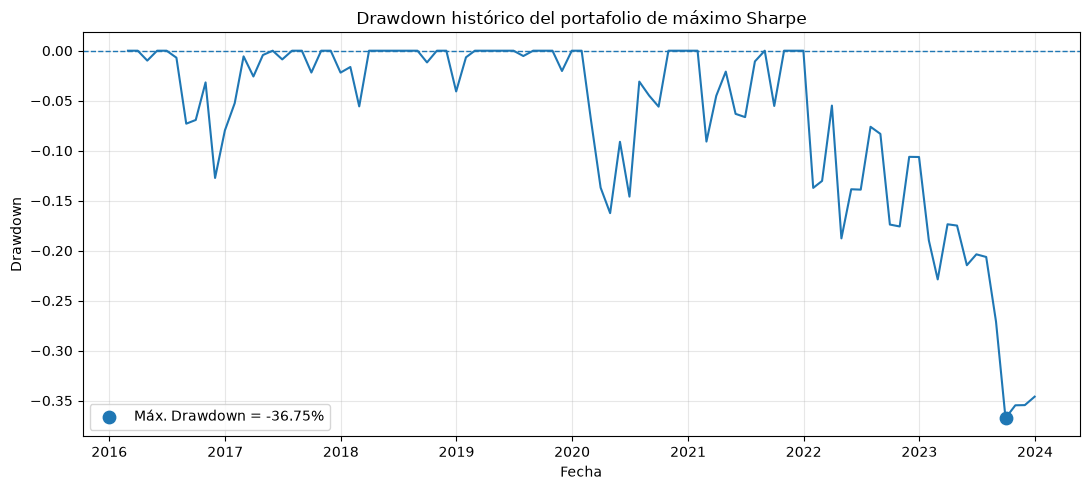

In [33]:
# ============================================================
# PASO 43 — Drawdown y Maximum Drawdown
# ============================================================

# Crecimiento acumulado de US$1 invertido
valor_acumulado = (1 + retornos_portafolio).cumprod()

# Máximo histórico alcanzado hasta cada fecha
maximo_acumulado = valor_acumulado.cummax()

# Drawdown
drawdown = valor_acumulado / maximo_acumulado - 1

# Maximum Drawdown
max_drawdown = drawdown.min()
fecha_max_drawdown = drawdown.idxmin()

print("Análisis de Drawdown del portafolio")
print("-" * 40)

print(f"Maximum Drawdown: {max_drawdown:.2%}")
print(f"Fecha del Maximum Drawdown: {fecha_max_drawdown}")

# Gráfico
plt.figure(figsize=(11, 5))

plt.plot(drawdown.index, drawdown)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.scatter(
    fecha_max_drawdown,
    max_drawdown,
    s=80,
    label=f"Máx. Drawdown = {max_drawdown:.2%}"
)

plt.title("Drawdown histórico del portafolio de máximo Sharpe")
plt.xlabel("Fecha")
plt.ylabel("Drawdown")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# PASO 44 — Resumen final de métricas de riesgo
# ============================================================

resumen_riesgo = pd.DataFrame({
    "Métrica": [
        "Retorno mensual promedio",
        "Volatilidad mensual",
        "VaR histórico 95%",
        "VaR histórico 99%",
        "Expected Shortfall 95%",
        "Expected Shortfall 99%",
        "Maximum Drawdown",
        "Peor retorno mensual"
    ],
    "Resultado": [
        retornos_portafolio.mean(),
        retornos_portafolio.std(),
        var_95,
        var_99,
        es_95,
        es_99,
        abs(max_drawdown),
        abs(retornos_portafolio.min())
    ]
})

resumen_riesgo["Resultado"] = resumen_riesgo["Resultado"].map(
    lambda x: f"{x:.2%}"
)

print("Resumen final de riesgo del portafolio:")
display(resumen_riesgo)

Resumen final de riesgo del portafolio:


,Métrica,Resultado
0,Retorno mensual promedio,0.76%
1,Volatilidad mensual,5.38%
2,VaR histórico 95%,9.50%
3,VaR histórico 99%,13.74%
4,Expected Shortfall 95%,12.15%
5,Expected Shortfall 99%,14.05%
6,Maximum Drawdown,36.75%
7,Peor retorno mensual,14.05%


## Conclusiones del análisis

El análisis realizado muestra que los activos eléctricos estudiados presentan correlaciones positivas relativamente elevadas, por lo que los beneficios de diversificación existen, pero son limitados. NEE presenta la menor correlación promedio con el resto de los activos, mientras que DUK adquiere el mayor peso dentro del portafolio de mínima varianza.

Los modelos de regresión muestran que las variables macrofinancieras consideradas explican una proporción relativamente baja de las variaciones mensuales de los retornos. Entre ellas, el VIX presenta una relación negativa y estadísticamente significativa con los retornos de los distintos activos, lo que evidencia la sensibilidad del sector a aumentos en la incertidumbre del mercado.

Al incorporar modelos GARCH(1,1), se observa que la volatilidad no necesariamente permanece constante a través del tiempo. La utilización de volatilidades condicionales modifica de manera importante la composición del portafolio de máximo Sharpe: bajo el enfoque histórico, el portafolio se concentra principalmente en NEE, mientras que al incorporar GARCH aumenta considerablemente la participación de EXC. Esto demuestra que la forma en que se modela el riesgo puede afectar directamente las decisiones de asignación de activos.

Finalmente, las medidas de riesgo de cola muestran que el portafolio sigue expuesto a pérdidas relevantes. El VaR histórico al 95% alcanza aproximadamente 9,50% mensual y el Expected Shortfall al mismo nivel aumenta a 12,15%. Además, el Maximum Drawdown histórico alcanza 36,75%, mostrando que incluso un portafolio optimizado puede experimentar pérdidas acumuladas importantes durante períodos adversos.

En conjunto, los resultados muestran que la optimización media-varianza es útil para estructurar el portafolio, pero debe complementarse con modelos de volatilidad dinámica y medidas de riesgo de cola como VaR, Expected Shortfall y Drawdown para obtener una evaluación más completa del riesgo financiero.

In [35]:
# ============================================================
# ETAPA 3 - Identificación de períodos de alta volatilidad GARCH
# ============================================================

resultados_picos = []

for ticker in tickers:
    
    serie_vol = volatilidad_garch[ticker].dropna()
    
    promedio = serie_vol.mean()
    desviacion = serie_vol.std()
    
    # Consideramos "alta volatilidad" cuando supera
    # promedio + 1 desviación estándar
    umbral = promedio + desviacion
    
    periodos_altos = serie_vol[serie_vol > umbral]
    
    if len(periodos_altos) > 0:
        fecha_max = periodos_altos.idxmax()
        vol_max = periodos_altos.max()
        
        resultados_picos.append({
            "Activo": ticker,
            "Volatilidad promedio": promedio,
            "Umbral alta volatilidad": umbral,
            "Fecha máximo": fecha_max,
            "Volatilidad máxima": vol_max,
            "Meses sobre umbral": len(periodos_altos)
        })

tabla_picos = pd.DataFrame(resultados_picos).set_index("Activo")

print("Períodos de mayor volatilidad condicional GARCH:")
display(tabla_picos)

Períodos de mayor volatilidad condicional GARCH:


,Volatilidad promedio,Umbral alta volatilidad,Fecha máximo,Volatilidad máxima,Meses sobre umbral
Activo,,,,,
NEE,0.0550,0.0678,2022-05,0.0841,19
DUK,0.0491,0.0506,2023-12,0.0516,20
SO,0.0521,0.0550,2023-12,0.0569,20
AEP,0.0524,0.0565,2020-11,0.0625,15
EXC,0.0505,0.0510,2016-02,0.0530,10


In [36]:
# ============================================================
# ETAPA 3 - Meses de alta volatilidad por activo
# ============================================================

for ticker in tickers:
    
    serie_vol = volatilidad_garch[ticker].dropna()
    
    promedio = serie_vol.mean()
    desviacion = serie_vol.std()
    umbral = promedio + desviacion
    
    periodos_altos = serie_vol[serie_vol > umbral]
    
    print(f"\n{ticker}")
    print(f"Umbral: {umbral:.4f}")
    
    if len(periodos_altos) > 0:
        display(periodos_altos.to_frame("Volatilidad GARCH"))
    else:
        print("No se detectaron meses sobre el umbral.")


NEE
Umbral: 0.0678


,Volatilidad GARCH
Date,
2022-02,0.0797
2022-03,0.0750
2022-04,0.0740
2022-05,0.0841
2022-06,0.0839
2022-07,0.0807
2022-08,0.0816
2022-09,0.0767
2022-10,0.0733



DUK
Umbral: 0.0506


,Volatilidad GARCH
Date,
2022-05,0.0506
2022-06,0.0507
2022-07,0.0507
2022-08,0.0508
2022-09,0.0508
2022-10,0.0509
2022-11,0.0509
2022-12,0.0510
2023-01,0.0510



SO
Umbral: 0.0550


,Volatilidad GARCH
Date,
2022-05,0.0550
2022-06,0.0551
2022-07,0.0552
2022-08,0.0553
2022-09,0.0554
2022-10,0.0555
2022-11,0.0556
2022-12,0.0557
2023-01,0.0558



AEP
Umbral: 0.0565


,Volatilidad GARCH
Date,
2020-09,0.0583
2020-10,0.0569
2020-11,0.0625
2020-12,0.0618
2021-01,0.0594
2021-02,0.0571
2021-03,0.0572
2021-04,0.0618
2021-05,0.0599



EXC
Umbral: 0.0510


,Volatilidad GARCH
Date,
2016-02,0.0530
2016-03,0.0527
2016-04,0.0524
2016-05,0.0521
2016-06,0.0519
2016-07,0.0516
2016-08,0.0515
2016-09,0.0513
2016-10,0.0512


### Interpretación de los períodos de alta volatilidad

La estimación GARCH muestra que la volatilidad condicional no evoluciona de la misma forma para todos los activos. NEE presenta su principal período de alta volatilidad durante 2022 y parte de 2023, alcanzando un máximo de 8,41% en mayo de 2022. Este período coincide con un entorno de fuerte incertidumbre financiera, caracterizado por el aumento de la inflación y el inicio de un ciclo agresivo de alzas de tasas de interés por parte de la Reserva Federal durante 2022.

AEP presenta un aumento importante de volatilidad desde fines de 2020, con un máximo de 6,25% en noviembre de ese año, en un período todavía marcado por los efectos económicos y financieros asociados a la pandemia de COVID-19.

En DUK y SO, en cambio, la volatilidad GARCH presenta una evolución mucho más persistente y suave, alcanzando sus máximos hacia fines de 2023. Esto es consistente con los parámetros estimados del modelo GARCH, donde la persistencia de la volatilidad es muy elevada, por lo que estos máximos no necesariamente representan un shock puntual sino una acumulación persistente del riesgo estimado.

Finalmente, EXC presenta su mayor volatilidad estimada al comienzo de la muestra, en febrero de 2016. Debido a que este máximo ocurre prácticamente al inicio del período analizado, debe interpretarse con cautela, ya que puede estar influido por las condiciones iniciales utilizadas en la estimación del modelo GARCH.

En conjunto, los resultados muestran que la volatilidad es dinámica y persistente, justificando el uso de una medida de riesgo condicional en lugar de asumir una volatilidad constante durante toda la muestra.

### Comparación del portafolio de máximo Sharpe

La composición del portafolio óptimo cambia de manera importante al sustituir la volatilidad histórica por la volatilidad condicional estimada mediante GARCH. Bajo el enfoque histórico, el portafolio de máximo Sharpe asigna 77,41% a NEE y 22,59% a EXC. Al incorporar las volatilidades GARCH, el peso de NEE disminuye a 47,60%, mientras que EXC aumenta hasta 52,40%.

Este cambio muestra que la estimación del riesgo utilizada influye directamente en la asignación óptima. En particular, NEE presenta una volatilidad GARCH anualizada relativamente elevada (23,98%), por lo que al reconocer este mayor nivel de riesgo condicional su participación en el portafolio disminuye. EXC, en cambio, presenta una volatilidad GARCH anualizada menor (17,40%), aumentando considerablemente su peso.

Por lo tanto, el portafolio óptimo no es invariante a la forma en que se mide el riesgo: reconocer que la volatilidad cambia en el tiempo modifica de manera sustancial la distribución entre NEE y EXC.

### Diversificación y portafolio de mínima varianza

NEE es el activo que presenta la menor correlación promedio con el resto del portafolio (0,6015), mientras que DUK es el activo que recibe el mayor peso en el portafolio de mínima varianza (41,22%). Por lo tanto, el activo con menor correlación promedio no es necesariamente el que obtiene la mayor ponderación.

Este resultado es consistente con la teoría de diversificación, ya que la optimización de mínima varianza no depende únicamente de las correlaciones entre los activos, sino también de sus volatilidades individuales y de las covarianzas del portafolio. Aunque NEE aporta beneficios de diversificación por su menor correlación con los demás activos, DUK presenta una combinación de riesgo y covarianza que permite reducir en mayor medida la varianza total del portafolio.

En consecuencia, una menor correlación favorece la diversificación, pero no implica automáticamente una mayor ponderación dentro del portafolio de mínima varianza.

In [38]:
# ============================================================
# ETAPA 5 - VaR condicional utilizando volatilidad GARCH
# ============================================================

from scipy.stats import norm
import numpy as np
import pandas as pd

# Usamos el portafolio elegido en la Etapa 4:
# máximo Sharpe basado en GARCH
pesos_var = pesos_max_sharpe_garch

# Retorno esperado mensual del portafolio
mu_port_mensual = np.dot(
    pesos_var,
    retornos_esperados_anuales.loc[tickers].values
) / 12

# Volatilidad condicional mensual del portafolio
# usando la matriz de covarianza GARCH anual de la Etapa 4
vol_garch_port_mensual = np.sqrt(
    pesos_var @ cov_garch_anual.values @ pesos_var
) / np.sqrt(12)

# VaR paramétrico condicional GARCH
z_95 = norm.ppf(0.95)
z_99 = norm.ppf(0.99)

var_garch_95 = z_95 * vol_garch_port_mensual - mu_port_mensual
var_garch_99 = z_99 * vol_garch_port_mensual - mu_port_mensual

print("VaR condicional GARCH:")
print(f"Retorno esperado mensual: {mu_port_mensual:.4%}")
print(f"Volatilidad GARCH mensual del portafolio: {vol_garch_port_mensual:.4%}")
print(f"VaR GARCH 95% mensual: {var_garch_95:.4%}")
print(f"VaR GARCH 99% mensual: {var_garch_99:.4%}")

VaR condicional GARCH:
Retorno esperado mensual: 0.6827%
Volatilidad GARCH mensual del portafolio: 5.2899%
VaR GARCH 95% mensual: 8.0185%
VaR GARCH 99% mensual: 11.6236%


In [39]:
# ============================================================
# Comparación final de VaR - Etapa 5
# ============================================================

tabla_var = pd.DataFrame({
    "VaR 95%": [
        var_normal_95,
        var_95,
        var_garch_95
    ],
    "VaR 99%": [
        var_normal_99,
        var_99,
        var_garch_99
    ]
}, index=[
    "Paramétrico histórico (Normal)",
    "Histórico empírico",
    "Condicional GARCH"
])

# Mostrar como porcentajes
tabla_var_pct = tabla_var.map(lambda x: f"{x:.2%}")

print("Comparación de métodos VaR:")
display(tabla_var_pct)

Comparación de métodos VaR:


,VaR 95%,VaR 99%
Paramétrico histórico (Normal),8.09%,11.76%
Histórico empírico,9.50%,13.74%
Condicional GARCH,8.02%,11.62%


### Interpretación de los resultados de VaR

Los resultados muestran diferencias relevantes según el método utilizado. El VaR paramétrico histórico estima una pérdida mensual de 8,09% al 95% y 11,76% al 99%, mientras que el VaR histórico empírico aumenta estas cifras a 9,50% y 13,74%, respectivamente. Por su parte, el VaR condicional GARCH alcanza 8,02% al 95% y 11,62% al 99%.

El método histórico empírico entrega las mayores pérdidas potenciales, especialmente al 99%. Esto es relevante considerando los resultados del test de Jarque-Bera de la Etapa 1, donde se observó evidencia de no normalidad en los retornos de algunos activos. Debido a que el VaR paramétrico supone una distribución normal, puede subestimar el riesgo cuando existen asimetrías, curtosis elevada o eventos extremos. El VaR histórico, en cambio, utiliza directamente la distribución observada de los retornos y conserva estos episodios extremos.

Además, el VaR condicional GARCH permite incorporar el hecho de que la volatilidad cambia en el tiempo. En este caso entrega valores ligeramente inferiores al VaR paramétrico histórico, lo que indica que la volatilidad condicional utilizada para el período reciente es algo menor que la estimada utilizando únicamente el riesgo histórico.

Por lo tanto, para este portafolio el VaR histórico empírico constituye una referencia especialmente relevante para evaluar pérdidas extremas, mientras que el VaR GARCH complementa el análisis al incorporar la naturaleza dinámica de la volatilidad. La diferencia entre los tres métodos demuestra que la estimación del riesgo depende tanto de los supuestos distributivos como de la forma en que se modela la volatilidad.

In [44]:
# ============================================================
# ETAPA 6 - Regímenes de mercado mediante Clustering
# Preparación definitiva de variables
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

# Pesos del portafolio máximo Sharpe GARCH
pesos_regimen = pesos_max_sharpe_garch

# Volatilidad GARCH ponderada del portafolio
vol_port_garch = volatilidad_garch[tickers].mul(
    pesos_regimen, axis=1
).sum(axis=1)

# Convertir VIX mensual al mismo tipo de índice que GARCH
vix_regimen = vix_mensual.copy()
vix_regimen.index = vix_regimen.index.to_period("M")

# Asegurar que la volatilidad GARCH tenga PeriodIndex mensual
if not isinstance(vol_port_garch.index, pd.PeriodIndex):
    vol_port_garch.index = vol_port_garch.index.to_period("M")

# Combinar por mes
datos_regimen = pd.concat(
    [vix_regimen, vol_port_garch],
    axis=1,
    join="inner"
).dropna()

datos_regimen.columns = [
    "VIX",
    "Volatilidad_GARCH_Portafolio"
]

print("Datos para análisis de regímenes:")
display(datos_regimen.head())

print("\nDimensión de la muestra:")
print(datos_regimen.shape)

print("\nEstadísticas descriptivas:")
display(datos_regimen.describe())

Datos para análisis de regímenes:


,VIX,Volatilidad_GARCH_Portafolio
Date,,
2016-02,20.5500,0.0497
2016-03,13.9500,0.0486
2016-04,15.7000,0.0480
2016-05,14.1900,0.0475
2016-06,15.6300,0.0467



Dimensión de la muestra:
(95, 2)

Estadísticas descriptivas:


,VIX,Volatilidad_GARCH_Portafolio
count,95.0000,95.0000
mean,18.9506,0.0526
std,7.5945,0.0060
min,9.5100,0.0439
25%,13.4800,0.0477
50%,16.7600,0.0522
75%,21.5000,0.0566
max,53.5400,0.0664


In [45]:
# ============================================================
# ETAPA 6 - K-means: identificación de regímenes de mercado
# ============================================================

# Estandarizar las variables
scaler = StandardScaler()
X_regimen = scaler.fit_transform(
    datos_regimen[["VIX", "Volatilidad_GARCH_Portafolio"]]
)

# K-means con 2 regímenes y semilla fija
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

datos_regimen["Cluster"] = kmeans.fit_predict(X_regimen)

# Promedios de cada cluster
resumen_clusters = datos_regimen.groupby("Cluster")[
    ["VIX", "Volatilidad_GARCH_Portafolio"]
].agg(["mean", "min", "max", "count"])

print("Características de los clusters:")
display(resumen_clusters)

# El cluster con mayor VIX promedio será considerado "Estrés"
vix_promedio_cluster = datos_regimen.groupby("Cluster")["VIX"].mean()

cluster_estres = vix_promedio_cluster.idxmax()
cluster_calma = vix_promedio_cluster.idxmin()

datos_regimen["Regimen"] = datos_regimen["Cluster"].map({
    cluster_calma: "Calma",
    cluster_estres: "Estrés"
})

print("\nNúmero de meses por régimen:")
display(datos_regimen["Regimen"].value_counts())

print("\nPromedios por régimen:")
display(
    datos_regimen.groupby("Regimen")[
        ["VIX", "Volatilidad_GARCH_Portafolio"]
    ].mean()
)

Características de los clusters:


VIX                       Volatilidad_GARCH_Portafolio         \
           mean     min     max count                         mean    min   
Cluster                                                                     
0       25.7494 12.9200 53.5400    36                       0.0576 0.0473   
1       14.8022  9.5100 25.4200    59                       0.0496 0.0439   

                      
           max count  
Cluster               
0       0.0664    36  
1       0.0591    59


Número de meses por régimen:


Regimen
Calma     59
Estrés    36
Name: count, dtype: int64


Promedios por régimen:


,VIX,Volatilidad_GARCH_Portafolio
Regimen,,
Calma,14.8022,0.0496
Estrés,25.7494,0.0576


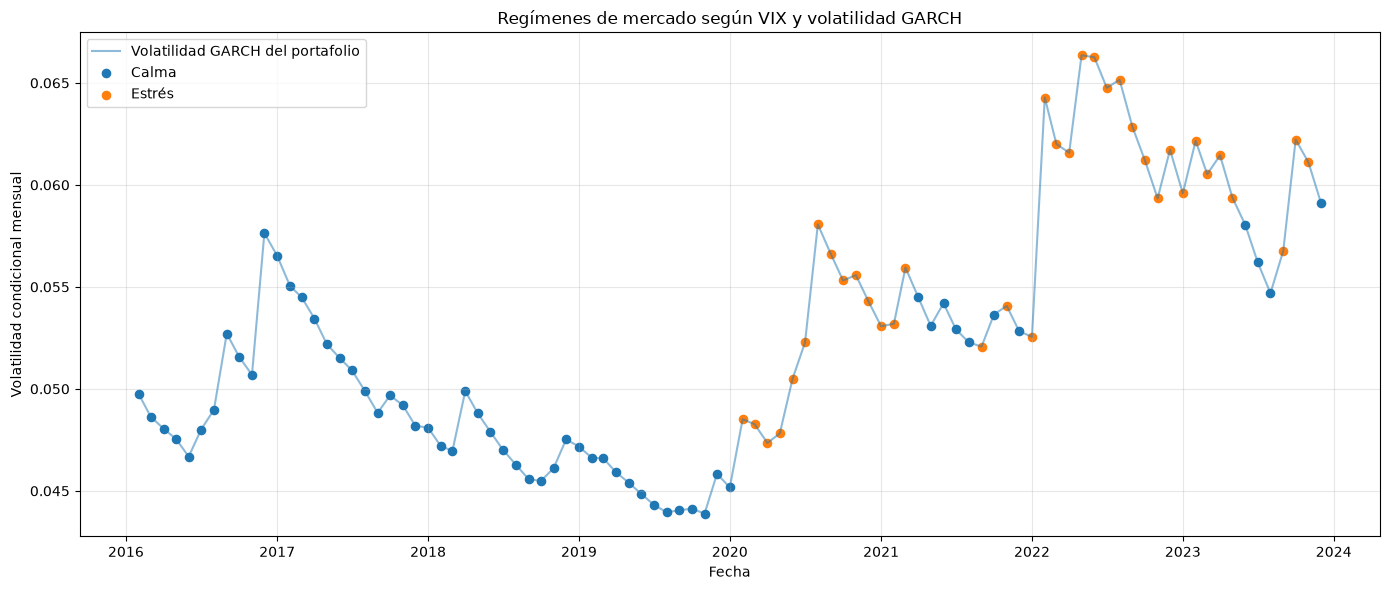

In [46]:
# ============================================================
# ETAPA 6 - Serie temporal coloreada por régimen
# ============================================================

import matplotlib.pyplot as plt

# Convertir PeriodIndex a fechas para graficar
fechas_regimen = datos_regimen.index.to_timestamp()

plt.figure(figsize=(14, 6))

# Línea de volatilidad
plt.plot(
    fechas_regimen,
    datos_regimen["Volatilidad_GARCH_Portafolio"],
    alpha=0.5,
    label="Volatilidad GARCH del portafolio"
)

# Meses de calma
mask_calma = datos_regimen["Regimen"] == "Calma"

plt.scatter(
    fechas_regimen[mask_calma],
    datos_regimen.loc[mask_calma, "Volatilidad_GARCH_Portafolio"],
    label="Calma",
    s=35
)

# Meses de estrés
mask_estres = datos_regimen["Regimen"] == "Estrés"

plt.scatter(
    fechas_regimen[mask_estres],
    datos_regimen.loc[mask_estres, "Volatilidad_GARCH_Portafolio"],
    label="Estrés",
    s=35
)

plt.title("Regímenes de mercado según VIX y volatilidad GARCH")
plt.xlabel("Fecha")
plt.ylabel("Volatilidad condicional mensual")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
# ============================================================
# ETAPA 6 - VaR histórico por régimen de mercado
# ============================================================

# Convertir el índice de retornos del portafolio a PeriodIndex mensual
retornos_regimen = retornos_portafolio.copy()

if not isinstance(retornos_regimen.index, pd.PeriodIndex):
    retornos_regimen.index = retornos_regimen.index.to_period("M")

# Combinar retornos con los regímenes identificados
analisis_var_regimen = pd.concat(
    [
        retornos_regimen.rename("Retorno_Portafolio"),
        datos_regimen["Regimen"]
    ],
    axis=1,
    join="inner"
).dropna()

# Separar retornos según régimen
ret_calma = analisis_var_regimen.loc[
    analisis_var_regimen["Regimen"] == "Calma",
    "Retorno_Portafolio"
]

ret_estres = analisis_var_regimen.loc[
    analisis_var_regimen["Regimen"] == "Estrés",
    "Retorno_Portafolio"
]

# VaR histórico
var_calma_95 = -np.percentile(ret_calma, 5)
var_calma_99 = -np.percentile(ret_calma, 1)

var_estres_95 = -np.percentile(ret_estres, 5)
var_estres_99 = -np.percentile(ret_estres, 1)

# Tabla comparativa
tabla_var_regimen = pd.DataFrame({
    "VaR 95%": [var_calma_95, var_estres_95],
    "VaR 99%": [var_calma_99, var_estres_99],
    "N° meses": [len(ret_calma), len(ret_estres)]
}, index=["Calma", "Estrés"])

tabla_var_regimen_pct = tabla_var_regimen.copy()
tabla_var_regimen_pct["VaR 95%"] = tabla_var_regimen_pct["VaR 95%"].map(
    lambda x: f"{x:.2%}"
)
tabla_var_regimen_pct["VaR 99%"] = tabla_var_regimen_pct["VaR 99%"].map(
    lambda x: f"{x:.2%}"
)

print("VaR histórico del portafolio por régimen de mercado:")
display(tabla_var_regimen_pct)

VaR histórico del portafolio por régimen de mercado:


,VaR 95%,VaR 99%,N° meses
Calma,4.55%,8.87%,59
Estrés,13.36%,13.94%,36


Interpretación de los regímenes de mercado:
El análisis muestra que distinguir entre regímenes de calma y estrés es relevante para la gestión del portafolio. En los 59 meses clasificados como calma, el VaR histórico al 95% fue de 4,55%, mientras que en los 36 meses de estrés aumentó a 13,36%. Al 99%, los valores fueron 8,87% y 13,94%, respectivamente. Esto evidencia que el riesgo de pérdida no permanece constante en el tiempo y aumenta considerablemente durante períodos de tensión de mercado. Si se hubiera conocido previamente el régimen de mercado, la decisión de inversión habría considerado explícitamente esta información, especialmente en períodos de estrés, donde habría sido razonable adoptar una postura más conservadora frente al riesgo. Por lo tanto, el análisis por regímenes complementa los resultados obtenidos mediante GARCH y muestra que una única estimación de VaR para toda la muestra puede ocultar diferencias importantes entre distintos estados del mercado.

In [50]:
# ============================================================
# COMPARACIÓN CON PORTAFOLIO EQUIPONDERADO
# ============================================================

# Portafolio equiponderado: 20% en cada activo
pesos_eq = np.repeat(1 / len(tickers), len(tickers))

# Función para calcular retorno, volatilidad y Sharpe
def metricas_portafolio(pesos, retornos_anuales, matriz_cov):
    retorno = np.dot(pesos, retornos_anuales)
    volatilidad = np.sqrt(pesos @ matriz_cov.values @ pesos)
    sharpe = retorno / volatilidad
    return retorno, volatilidad, sharpe

# 1. Equiponderado con riesgo histórico
ret_eq_hist, vol_eq_hist, sharpe_eq_hist = metricas_portafolio(
    pesos_eq,
    retornos_esperados_anuales.values,
    cov_anual
)

# 2. Máximo Sharpe con riesgo histórico
ret_opt_hist, vol_opt_hist, sharpe_opt_hist = metricas_portafolio(
    pesos_max_sharpe_hist,
    retornos_esperados_anuales.values,
    cov_anual
)

# 3. Equiponderado usando volatilidades GARCH
ret_eq_garch, vol_eq_garch, sharpe_eq_garch = metricas_portafolio(
    pesos_eq,
    retornos_esperados_anuales.values,
    cov_garch_anual
)

# 4. Máximo Sharpe usando volatilidades GARCH
ret_opt_garch, vol_opt_garch, sharpe_opt_garch = metricas_portafolio(
    pesos_max_sharpe_garch,
    retornos_esperados_anuales.values,
    cov_garch_anual
)

# Tabla comparativa
comparacion_equiponderado = pd.DataFrame({
    "Portafolio": [
        "Equiponderado - Histórico",
        "Máx. Sharpe - Histórico",
        "Equiponderado - GARCH",
        "Máx. Sharpe - GARCH"
    ],
    "Retorno esperado": [
        ret_eq_hist,
        ret_opt_hist,
        ret_eq_garch,
        ret_opt_garch
    ],
    "Volatilidad": [
        vol_eq_hist,
        vol_opt_hist,
        vol_eq_garch,
        vol_opt_garch
    ],
    "Sharpe": [
        sharpe_eq_hist,
        sharpe_opt_hist,
        sharpe_eq_garch,
        sharpe_opt_garch
    ]
})

# Mostrar porcentajes de forma legible
tabla_comparacion = comparacion_equiponderado.copy()
tabla_comparacion["Retorno esperado"] = tabla_comparacion["Retorno esperado"].map(
    lambda x: f"{x:.2%}"
)
tabla_comparacion["Volatilidad"] = tabla_comparacion["Volatilidad"].map(
    lambda x: f"{x:.2%}"
)
tabla_comparacion["Sharpe"] = tabla_comparacion["Sharpe"].map(
    lambda x: f"{x:.4f}"
)

print("Comparación: portafolio equiponderado vs. máximo Sharpe")
display(tabla_comparacion)

Comparación: portafolio equiponderado vs. máximo Sharpe


,Portafolio,Retorno esperado,Volatilidad,Sharpe
0,Equiponderado - Histórico,5.58%,16.73%,0.3336
1,Máx. Sharpe - Histórico,9.12%,18.64%,0.4889
2,Equiponderado - GARCH,5.58%,17.07%,0.3270
3,Máx. Sharpe - GARCH,8.19%,18.32%,0.4471


# Informe Final

## 1. ¿Qué explica el comportamiento de cada activo?

Las regresiones realizadas para NEE, DUK, SO, AEP y EXC muestran que los factores macroeconómicos considerados explican solo una parte acotada de sus retornos, con R² entre 0,0819 y 0,1128. El VIX resultó estadísticamente significativo para los cinco activos y presentó coeficientes negativos, indicando que aumentos en la incertidumbre del mercado se relacionan con menores retornos de las acciones analizadas. La tasa GS10 fue significativa al 5% únicamente para NEE, mientras que el spread de tasas no fue significativo para ninguno de los activos. En consecuencia, aunque existe exposición a factores sistemáticos —especialmente al VIX—, una parte importante del comportamiento de estas acciones permanece sin explicar por las variables macro utilizadas y corresponde a componentes idiosincráticos. El análisis posterior mediante GARCH confirmó además que este riesgo residual no permanece constante en el tiempo.

## 2. ¿Es mejor el portafolio óptimo que uno equiponderado y bajo qué supuesto de volatilidad?

El portafolio de máximo Sharpe presenta un mejor retorno ajustado por riesgo que el equiponderado bajo ambos supuestos de volatilidad. Utilizando la matriz histórica, el portafolio equiponderado obtuvo un retorno esperado de 5,58%, volatilidad de 16,73% y Sharpe de 0,3336, mientras que el máximo Sharpe alcanzó 9,12%, 18,64% y 0,4889, respectivamente. Al incorporar volatilidades GARCH, el equiponderado obtuvo un Sharpe de 0,3270 frente a 0,4471 del portafolio optimizado. Sin embargo, la composición óptima es sensible al supuesto de riesgo: con volatilidad histórica se asignó 77,41% a NEE y 22,59% a EXC, mientras que utilizando GARCH los pesos cambiaron a 47,60% y 52,40%, respectivamente. Por lo tanto, la optimización mejora la relación retorno-riesgo frente a una asignación ingenua, pero la composición recomendada depende de cómo se modele la volatilidad.

## 3. ¿Cuánto podría perder el cliente en un mal mes y qué tan sensible es esa cifra al método utilizado?

El riesgo estimado depende del método utilizado. El VaR histórico fue de 9,50% al 95% y 13,74% al 99%, mientras que el VaR paramétrico normal fue menor, con 8,09% y 11,76%, respectivamente. Al incorporar volatilidad condicional mediante GARCH, los valores fueron 8,02% al 95% y 11,62% al 99%. Además, el Expected Shortfall histórico alcanzó 12,15% al 95% y 14,05% al 99%, mostrando que las pérdidas pueden ser considerablemente mayores una vez superado el VaR. El peor retorno mensual observado fue -14,05%. En consecuencia, para comunicar el riesgo de un “mal mes” resulta prudente considerar no solo el VaR, sino también las pérdidas observadas en la cola de la distribución, ya que el método histórico refleja pérdidas extremas que el supuesto de normalidad puede subestimar. El análisis por regímenes refuerza esta conclusión: el VaR histórico al 95% aumentó desde 4,55% en períodos de calma hasta 13,36% en períodos de estrés.